#  Cellular Network Performance Modeling Project

##  Overview

In the telecommunications industry, maintaining high-quality cellular network performance is critical for customer satisfaction, retention, and operational efficiency. This project uses a real-world dataset containing geolocated signal measurements and network performance metrics to analyze and model key indicators of network health. By combining regression and classification approaches, the aim is to evaluate and predict network performance and classify zones based on service quality.

---

## Problem Statement

Mobile network operators face challenges in ensuring consistent service quality across regions. Variability in signal strength, data throughput, and latency can result in user dissatisfaction, especially in high-traffic or underserved areas. There is a need to:

- Accurately predict network performance metrics at any given location and time.
- Identify and classify zones by quality of service.
- Predict the network type (3G, 4G, 5G, etc.) based on environmental and signal parameters.

---

##  Project Objectives

### Primary Objectives

1. **Regression**:
   - Predict continuous performance metrics:
     - Signal Strength (dBm)
     - Data Throughput (Mbps)
     

2. **Classification**:
   - Classify zones into service quality levels: **Good**, **Moderate**, or **Poor**.
   - Predict the **network type** (e.g., 3G, 4G, 5G) based on observed signal and performance data.



###  Secondary Objectives

- Compare the reliability of different signal measurement tools (BB60C, srsRAN, BladeRFxA9).
- Understand correlation between geographic, temporal, and signal-related factors.

---

##  Metrics of Success

###  Technical Success Metrics

| Task | Metrics |
|------|---------|
| Regression (Signal/Throughput/Latency) | RMSE, MAE, R² |
| Network Type Classification | Accuracy, Confusion Matrix, ROC-AUC |
| Feature Importance | Gain-based or SHAP value insights |

###  Business Success Metrics

| Goal | Indicator |
|------|-----------|
| Improved coverage planning | Identifying underserved zones with >90% accuracy |
| Network type predictability | >80% accuracy in predicting network types |
| Targeted optimization | Actionable insights for at least 3 key zones |
| Scalability | Model generalizes well to new geolocations |


#  Data Understanding – Cellular Network Performance Project

##  Dataset Overview

This dataset contains signal quality measurements from various geographic locations and cellular network types. The goal is to assess and model the quality of service across different network types and environments.

---

##  Key Features

| Column Name        | Description |
|--------------------|-------------|
| `latitude`         | Latitude coordinate where signal was measured |
| `longitude`        | Longitude coordinate where signal was measured |
| `timestamp`        | Time of measurement |
| `tool`             | Measurement tool used (e.g., BB60C, srsRAN, BladeRFxA9) |
| `network_type`     | Type of mobile network (3G, 4G, LTE, 5G) |
| `locality`         | Area classification (Urban, Suburban, Rural) |
| `signal_strength`  | Signal power in dBm |
| `signal_quality`   | Quality of the signal (percentage) |
| `data_throughput`  | Data transmission speed (Mbps) |
| `latency`          | Network delay in milliseconds (ms) |

---





# Exploring the dataset


In [1]:
# Importing the necessary libraries
#Data manipulation
import pandas as pd
import numpy as np

#Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer

# Models
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import classification_report,accuracy_score,f1_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Loading the dataset
df = pd.read_csv('signal_metrics.csv')
df

,Timestamp,Locality,Latitude,Longitude,Signal Strength (dBm),Signal Quality (%),Data Throughput (Mbps),Latency (ms),Network Type,BB60C Measurement (dBm),srsRAN Measurement (dBm),BladeRFxA9 Measurement (dBm)
0,2023-05-05 12:50:40.000000,Anisabad,25.599109,85.137355,-84.274113,0.0,1.863890,129.122914,3G,0.000000,0.000000,0.000000
1,2023-05-05 12:53:47.210173,Fraser Road,25.433286,85.070053,-97.653121,0.0,5.132296,54.883606,4G,-95.810791,-105.452359,-99.920892
2,2023-05-05 12:56:54.420346,Boring Canal Road,25.498809,85.211371,-87.046134,0.0,1.176985,119.598286,LTE,-91.593861,-95.419482,-87.714070
3,2023-05-05 13:00:01.630519,Danapur,25.735138,85.208400,-94.143159,0.0,68.596932,46.598387,5G,-90.642773,-101.895905,-96.570698
4,2023-05-05 13:03:08.840692,Phulwari Sharif,25.538556,85.159860,-94.564765,0.0,38.292038,30.342828,5G,-90.489100,-103.318304,-95.102467
...,...,...,...,...,...,...,...,...,...,...,...,...
16824,2023-06-10 23:44:23.950552,Pataliputra,25.542846,85.129611,-92.024221,0.0,3.720856,53.376474,4G,-90.177947,-97.971619,-93.362041
16825,2023-06-10 23:47:31.160725,Boring Canal Road,25.724624,85.233365,-87.579509,0.0,2.117080,134.458401,LTE,-87.694985,-92.616868,-84.749607
16826,2023-06-10 23:50:38.370898,Boring Road,25.574020,85.030036,-90.451396,0.0,72.870842,32.556578,5G,-91.098875,-97.447725,-87.752628
16827,2023-06-10 23:53:45.581071,Boring Road,25.619325,85.183155,-85.661814,0.0,2.482843,144.007572,3G,0.000000,0.000000,0.000000


In [3]:
#Asserting the shape
df.shape

(16829, 12)

In [4]:
df.columns

Index(['Timestamp', 'Locality', 'Latitude', 'Longitude',
       'Signal Strength (dBm)', 'Signal Quality (%)', 'Data Throughput (Mbps)',
       'Latency (ms)', 'Network Type', 'BB60C Measurement (dBm)',
       'srsRAN Measurement (dBm)', 'BladeRFxA9 Measurement (dBm)'],
      dtype='object')

In [5]:
# Checking the data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16829 entries, 0 to 16828
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Timestamp                     16829 non-null  object 
 1   Locality                      16829 non-null  object 
 2   Latitude                      16829 non-null  float64
 3   Longitude                     16829 non-null  float64
 4   Signal Strength (dBm)         16829 non-null  float64
 5   Signal Quality (%)            16829 non-null  float64
 6   Data Throughput (Mbps)        16829 non-null  float64
 7   Latency (ms)                  16829 non-null  float64
 8   Network Type                  16829 non-null  object 
 9   BB60C Measurement (dBm)       16829 non-null  float64
 10  srsRAN Measurement (dBm)      16829 non-null  float64
 11  BladeRFxA9 Measurement (dBm)  16829 non-null  float64
dtypes: float64(9), object(3)
memory usage: 1.5+ MB


In [6]:
# Checking for statistical info for numerical values
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Latitude,16829.0,25.594796,0.089881,25.414575,25.522858,25.595383,25.667620,25.773648
Longitude,16829.0,85.137314,0.090095,84.957936,85.064124,85.138149,85.209504,85.316994
Signal Strength (dBm),16829.0,-90.072484,5.399368,-116.942267,-93.615962,-89.665566,-86.145491,-74.644848
Signal Quality (%),16829.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Data Throughput (Mbps),16829.0,16.182856,25.702734,1.000423,2.001749,2.997175,9.956314,99.985831
Latency (ms),16829.0,101.313624,56.010418,10.019527,50.320775,100.264318,149.951112,199.991081
BB60C Measurement (dBm),16829.0,-68.820150,40.046739,-115.667514,-94.021959,-89.126942,0.000000,0.000000
srsRAN Measurement (dBm),16829.0,-74.439562,43.215204,-124.652054,-101.249987,-96.838442,0.000000,0.000000
BladeRFxA9 Measurement (dBm),16829.0,-68.819930,39.996934,-119.207545,-93.749032,-89.282746,0.000000,0.000000


In [7]:
#Checking statistical information for objects
df.describe(include=object).T

,count,unique,top,freq
Timestamp,16829,16829,2023-05-05 12:50:40.000000,1
Locality,16829,20,Fraser Road,897
Network Type,16829,4,LTE,4224


In [8]:
#Checking for missing values
df.isnull().sum()

Timestamp                       0
Locality                        0
Latitude                        0
Longitude                       0
Signal Strength (dBm)           0
Signal Quality (%)              0
Data Throughput (Mbps)          0
Latency (ms)                    0
Network Type                    0
BB60C Measurement (dBm)         0
srsRAN Measurement (dBm)        0
BladeRFxA9 Measurement (dBm)    0
dtype: int64

In [9]:
#Checking for duplicates
df.duplicated().sum()

0

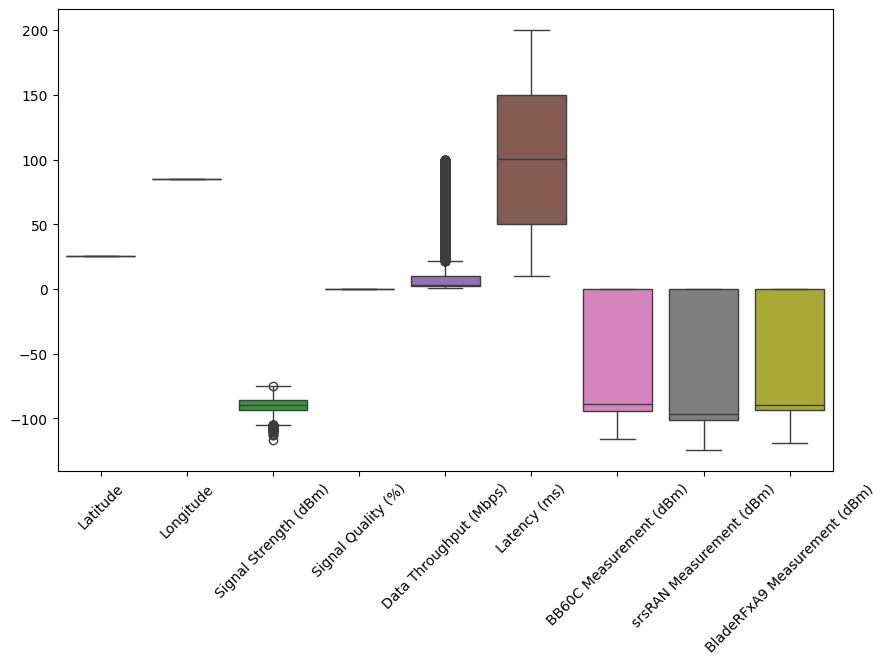

In [10]:
#Checking for outliers
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()

# Data Preparation

In [11]:
# Dropping unnecessary columns
df.drop(columns=['Locality'],axis=1,inplace=True)

In [12]:
#changing column format to lower case and handling white spaces
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(" ","_")

In [13]:
#Confirming th changes
df.head()

,timestamp,latitude,longitude,signal_strength_(dbm),signal_quality_(%),data_throughput_(mbps),latency_(ms),network_type,bb60c_measurement_(dbm),srsran_measurement_(dbm),bladerfxa9_measurement_(dbm)
0,2023-05-05 12:50:40.000000,25.599109,85.137355,-84.274113,0.0,1.863890,129.122914,3G,0.000000,0.000000,0.000000
1,2023-05-05 12:53:47.210173,25.433286,85.070053,-97.653121,0.0,5.132296,54.883606,4G,-95.810791,-105.452359,-99.920892
2,2023-05-05 12:56:54.420346,25.498809,85.211371,-87.046134,0.0,1.176985,119.598286,LTE,-91.593861,-95.419482,-87.714070
3,2023-05-05 13:00:01.630519,25.735138,85.208400,-94.143159,0.0,68.596932,46.598387,5G,-90.642773,-101.895905,-96.570698
4,2023-05-05 13:03:08.840692,25.538556,85.159860,-94.564765,0.0,38.292038,30.342828,5G,-90.489100,-103.318304,-95.102467


In [14]:
#Checking for unique values and value counts
df['network_type'].value_counts()

network_type
LTE    4224
4G     4219
3G     4208
5G     4178
Name: count, dtype: int64

In [15]:
df['signal_quality_(%)'].value_counts()

signal_quality_(%)
0.0    16829
Name: count, dtype: int64

In [16]:
df.drop(columns=['signal_quality_(%)'],axis=1,inplace=True)

## Feature Engineering

In [17]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['month'] = df['timestamp'].dt.month



In [18]:
def map_time_of_day(hour):
    if 0 <= hour <= 1:
        return "Midnight"
    elif 2 <= hour <= 3:
        return "Very Late Night"
    elif 4 <= hour <= 5:
        return "Pre-dawn"
    elif 6 <= hour <= 8:
        return "Early Morning"
    elif 9 <= hour <= 11:
        return "Mid-Morning"
    elif hour == 12:
        return "Midday"
    elif 13 <= hour <= 15:
        return "Early Afternoon"
    elif 16 <= hour <= 17:
        return "Late Afternoon"
    elif 18 <= hour <= 19:
        return "Early Evening"
    elif hour == 20:
        return "Late Evening"
    elif 21 <= hour <= 22:
        return "Night"
    elif hour == 23:
        return "Late Night"
    
    # Create new time-of-day feature
df['time_of_day'] = df['hour'].apply(map_time_of_day)

In [19]:
df.head()

,timestamp,latitude,longitude,signal_strength_(dbm),data_throughput_(mbps),latency_(ms),network_type,bb60c_measurement_(dbm),srsran_measurement_(dbm),bladerfxa9_measurement_(dbm),hour,day_of_week,month,time_of_day
0,2023-05-05 12:50:40.000000,25.599109,85.137355,-84.274113,1.863890,129.122914,3G,0.000000,0.000000,0.000000,12,4,5,Midday
1,2023-05-05 12:53:47.210173,25.433286,85.070053,-97.653121,5.132296,54.883606,4G,-95.810791,-105.452359,-99.920892,12,4,5,Midday
2,2023-05-05 12:56:54.420346,25.498809,85.211371,-87.046134,1.176985,119.598286,LTE,-91.593861,-95.419482,-87.714070,12,4,5,Midday
3,2023-05-05 13:00:01.630519,25.735138,85.208400,-94.143159,68.596932,46.598387,5G,-90.642773,-101.895905,-96.570698,13,4,5,Early Afternoon
4,2023-05-05 13:03:08.840692,25.538556,85.159860,-94.564765,38.292038,30.342828,5G,-90.489100,-103.318304,-95.102467,13,4,5,Early Afternoon


In [20]:
# saving the cleaned and engineered dataset
df.to_csv('cellular_network_dataset')

# Exploratory Data Analysis (EDA)

## Uni-variate Analysis

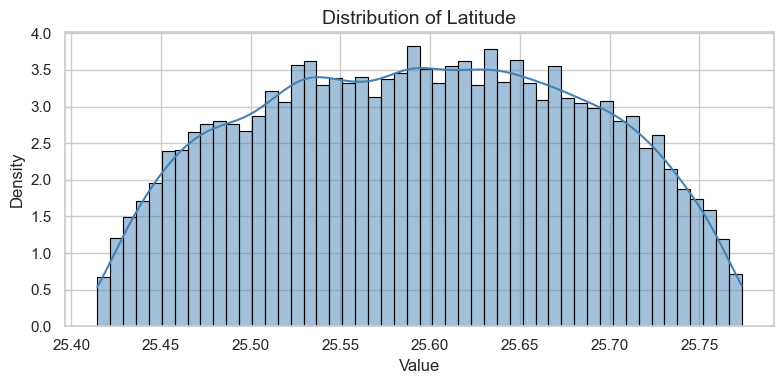

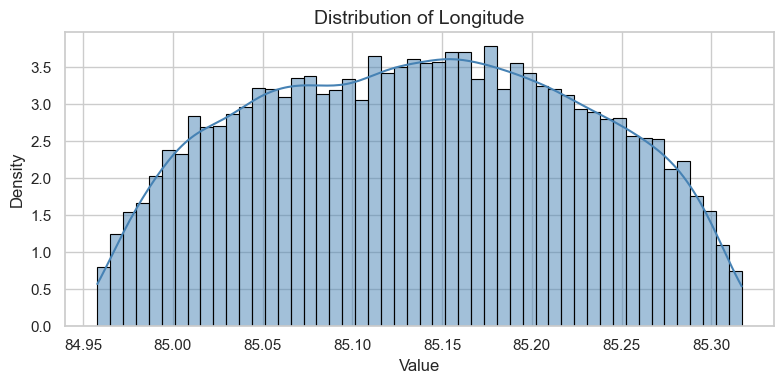

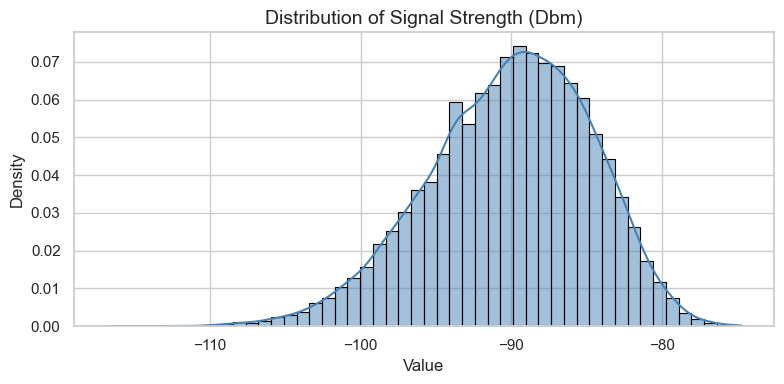

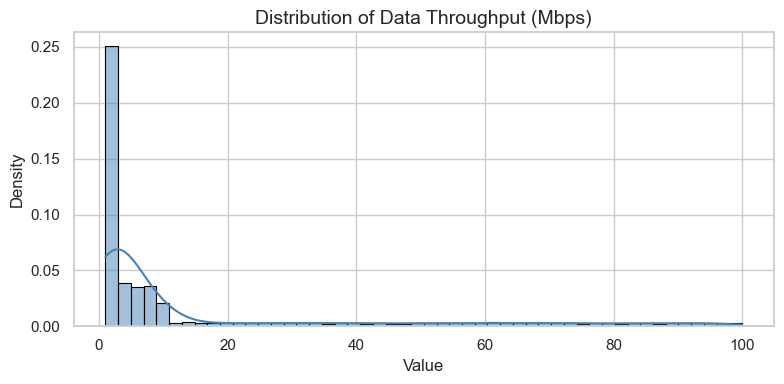

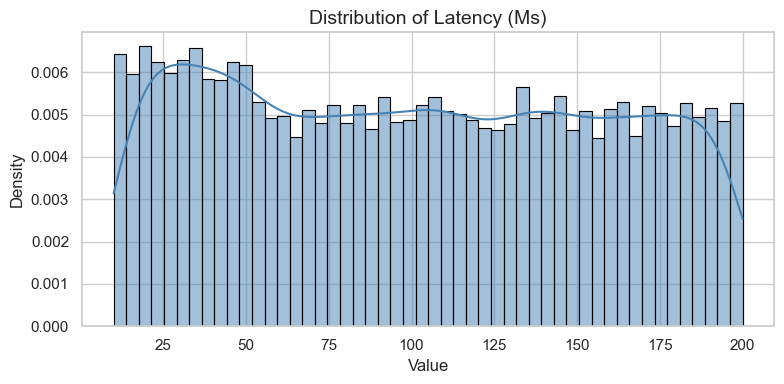

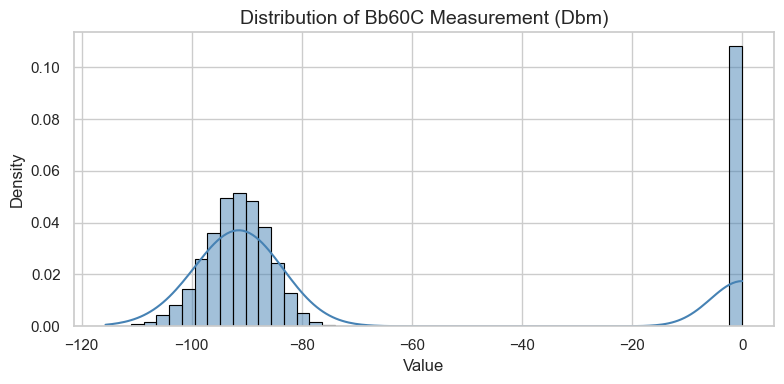

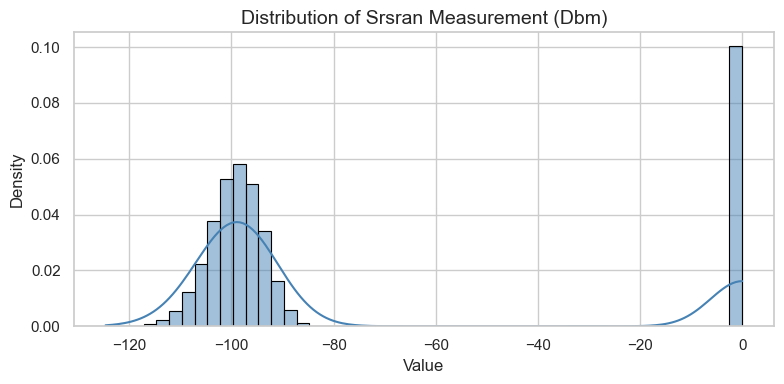

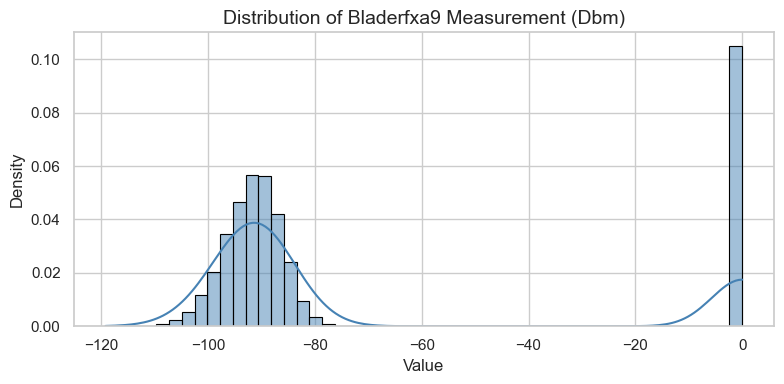

In [21]:
# Select all numeric columns
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns

# Set style
sns.set(style="whitegrid")

# Plot distributions
for col in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col].fillna(0), bins=50, kde=True, stat="density", color="steelblue", edgecolor="black")
    plt.title(f"Distribution of {col.replace('_', ' ').title()}", fontsize=14)
    plt.xlabel("Value", fontsize=12)
    plt.ylabel("Density", fontsize=12)
    plt.tight_layout()
    plt.show()


**Observations**

- **Signal Strength (dBm)**: The distribution is approximately normal, centered around -90 dBm, which represents typical signal strengths within the dataset.
- **Data Throughput (Mbps)**: This feature is highly skewed towards lower values, indicating that most measurements show lower data speeds, with fewer instances of high throughput.
- **Latency (ms)**: The distribution appears bimodal or multi-modal, suggesting a variety of network delays, potentially influenced by different network types or traffic conditions.
- **BB60C, srsRAN, and BladeRFxA9 Measurement (dBm)**: These measurement tools show a significant spike at 0 dBm, likely indicating missing or unrecorded measurements. When these values are excluded, the distributions for valid measurements appear somewhat similar to the main Signal Strength distribution.

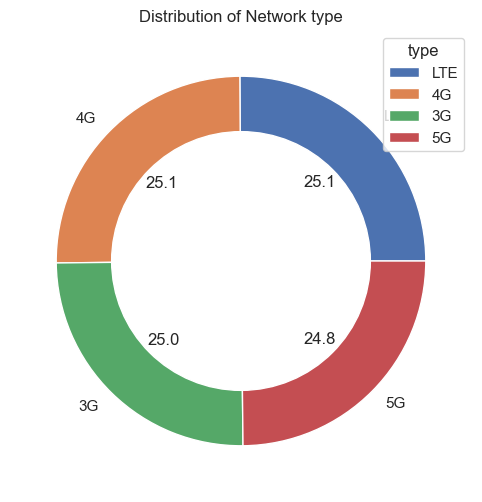

In [22]:
# Distribution of network type
network_count = df['network_type'].value_counts()
plt.figure(figsize=(10,6))
plt.pie(network_count,labels=network_count.index,autopct='%1.1f')

#Create blank circle
centre_circle =plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

#Customize the plot
plt.title('Distribution of Network type')
plt.legend(title='type',loc ='upper right')
plt.show()

**Observations**
1. **Proportions (Percentages)**: Each segment of the donut chart has a numerical label indicating its percentage contribution to the total.
- LTE: 25.1%
- 4G: 25.1%
- 3G: 25.0%
- 5G: 24.8%

2. **Near-Even Distribution**: A key observation is that all four network types have a very similar, almost equal, distribution. Each category accounts for approximately 25% of the total, suggesting a nearly uniform distribution among these network types.


## Bi-Variate Analysis

### Numeric Vs Numeric

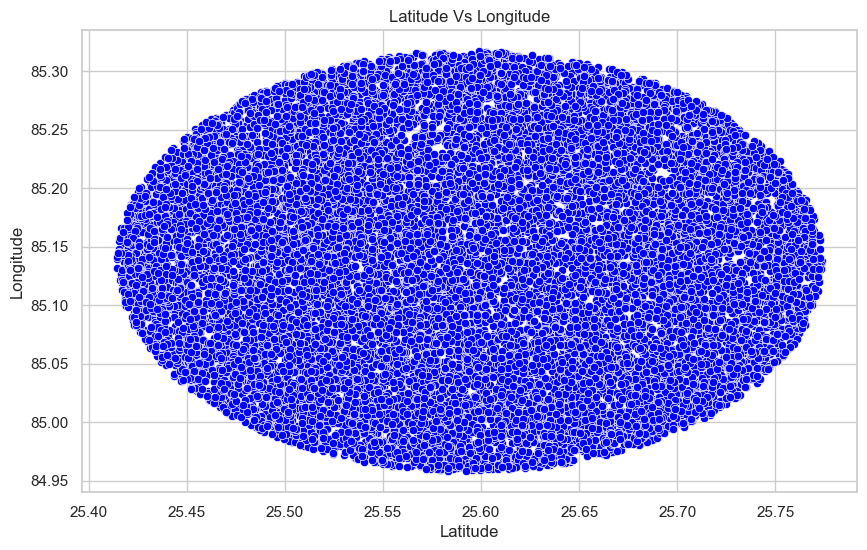

In [23]:
#Latitude vs Longitude
plt.figure(figsize=(10,6))
sns.scatterplot(x=df['latitude'],y=df['longitude'],color=('blue'),data=df)
plt.title('Latitude Vs Longitude')
plt.xlabel("Latitude")
plt.ylabel("Longitude")
plt.show()

**Observations**

- Data Distribution: The data points are densely packed and appear to form an oval or elliptical shape.
- Uniformity (Visual Impression): Within the oval shape, the data points seem to be distributed relatively uniformly. There are no obvious clusters or sparse areas within the main mass of points.

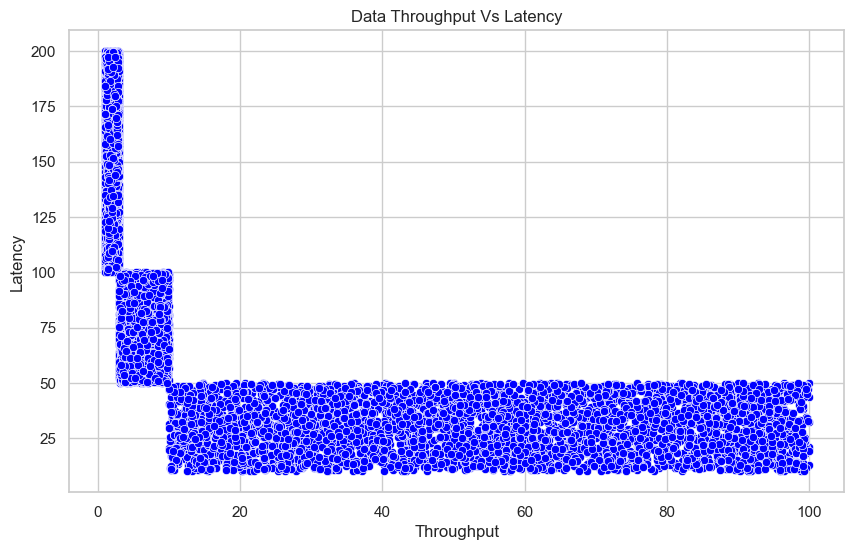

In [24]:
#Throughput vs Latency
plt.figure(figsize=(10,6))
sns.scatterplot(x=df['data_throughput_(mbps)'],y=df['latency_(ms)'],color=('blue'),data=df)
plt.title('Data Throughput Vs Latency')
plt.xlabel("Throughput")
plt.ylabel("Latency")
plt.show()

**Observations**

1. **Data Distribution** - L-Shape/Corner Pattern: The most striking observation is the distinct "L" or corner-like shape formed by the data points.
 - There's a dense vertical band of points at very low Throughput values (close to 0), extending roughly from a Latency of 50 up to 200.
 - There's a dense horizontal band of points at relatively low Latency values (between approximately 10 and 50), extending from a Throughput of around 5 up to 100.
 - There's also a smaller, denser rectangular cluster of points where both Throughput and Latency are low (e.g., Throughput 0-5 and Latency 50-100).

2. **Implied Relationship:** This distribution suggests that:
 - When Throughput is very low, Latency can be very high (up to 200).
 - When Latency is relatively low (below 50), Throughput can be quite high (up to 100).
 - There's a region where both Throughput and Latency are low, possibly indicating optimal performance conditions.

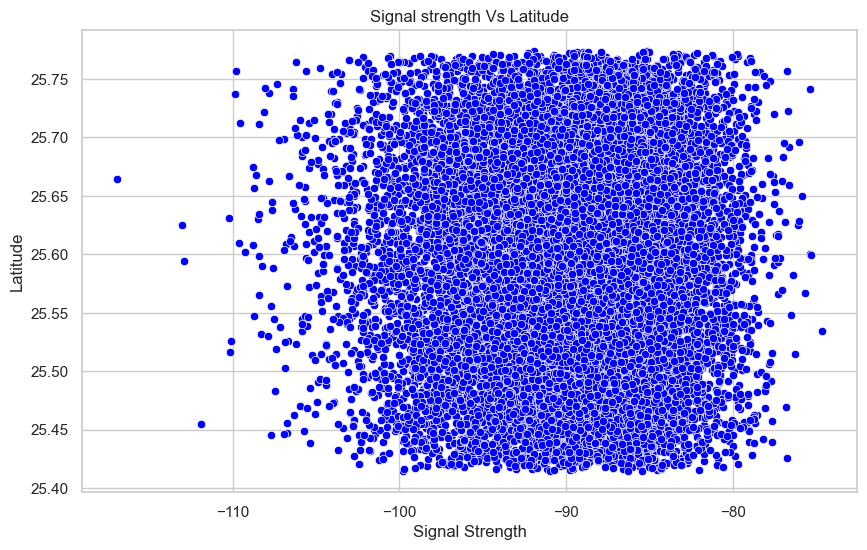

In [25]:
#Signal strength vs Latitude
plt.figure(figsize=(10,6))
sns.scatterplot(x=df['signal_strength_(dbm)'],y=df['latitude'],color=('blue'),data=df)
plt.title('Signal strength Vs Latitude')
plt.xlabel("Signal Strength")
plt.ylabel("Latitude")
plt.show()

**Observations**
- Data Distribution - Rectangular Cluster: The majority of the data points form a large, dense, somewhat rectangular cluster.
- Dense Core: Within this rectangular region, the points are extremely dense, suggesting a large number of observations.

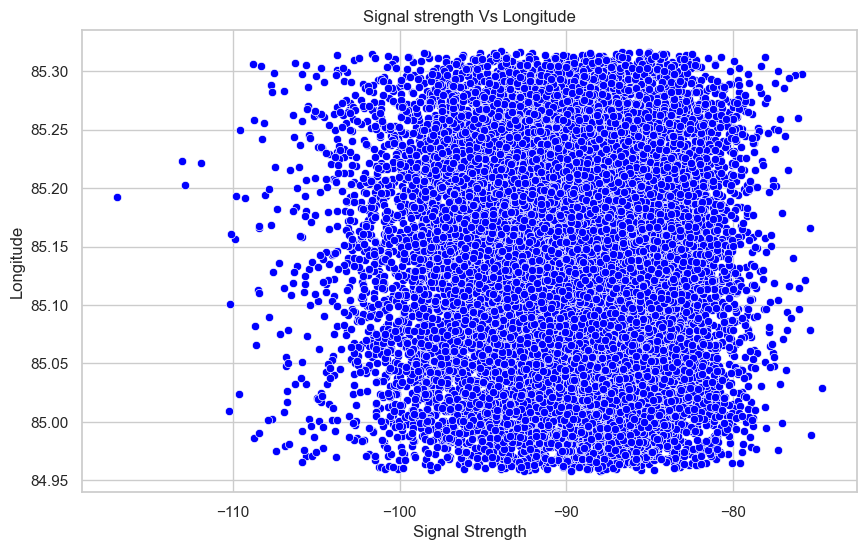

In [26]:
#Signal strength vs Longitude
plt.figure(figsize=(10,6))
sns.scatterplot(x=df['signal_strength_(dbm)'],y=df['longitude'],color=('blue'),data=df)
plt.title('Signal strength Vs Longitude')
plt.xlabel("Signal Strength")
plt.ylabel("Longitude")
plt.show()

**Observations**
- Data Distribution - Rectangular Cluster: The majority of the data points form a large, dense, somewhat rectangular cluster.
- Dense Core: Within this rectangular region, the points are very dense, suggesting a large number of observations within specific ranges of signal strength and longitude.

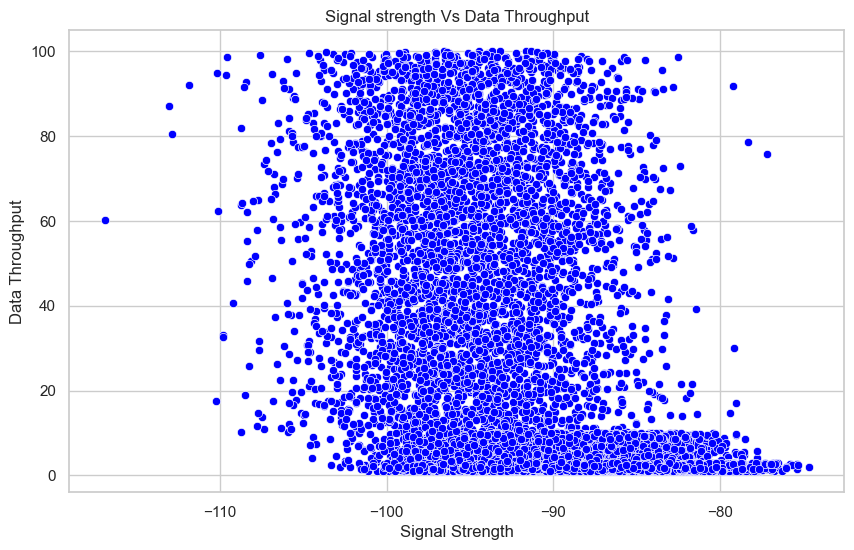

In [27]:
#Signal strength vs Throughput
plt.figure(figsize=(10,6))
sns.scatterplot(x=df['signal_strength_(dbm)'],y=df['data_throughput_(mbps)'],color=('blue'),data=df)
plt.title('Signal strength Vs Data Throughput')
plt.xlabel("Signal Strength")
plt.ylabel("Data Throughput")
plt.show()

**Observations**
1. **Data Distribution** - Inverted Trapezoid/Funnel Shape: The most prominent observation is the shape of the data distribution. It forms an approximate inverted trapezoid or funnel shape.
 - At higher (less negative) Signal Strength values (e.g., from -90 to -78), the Data Throughput values are mostly concentrated at the lower end (around 0 to 10), forming a dense, narrow band.
 - As Signal Strength decreases (becomes more negative, moving to the left), the range of observed Data Throughput values widens significantly.
 - For instance, at Signal Strength around -100, Data Throughput ranges from near 0 up to 100.
 - At the far left (around -110 Signal Strength), Data Throughput again appears to be more scattered but still covers a wide range.

2. **Implied Relationship:**
 - Strong Signal Strength (less negative): Tends to correspond to very low Data Throughput. This is counter-intuitive if higher signal strength is expected to mean better performance, and might suggest some other limiting factor or a specific scenario where strong signals result in low throughput.
 - Weaker Signal Strength (more negative): Allows for a much wider range of Data Throughput values, including high throughput. This is also interesting and suggests that strong signals might not be the primary determinant of high throughput in this dataset, or that other factors become more dominant with stronger signals.
 - Dense Area: The densest concentration of points is in the bottom-right corner, where Signal Strength is higher (less negative) and Data Throughput is very low.

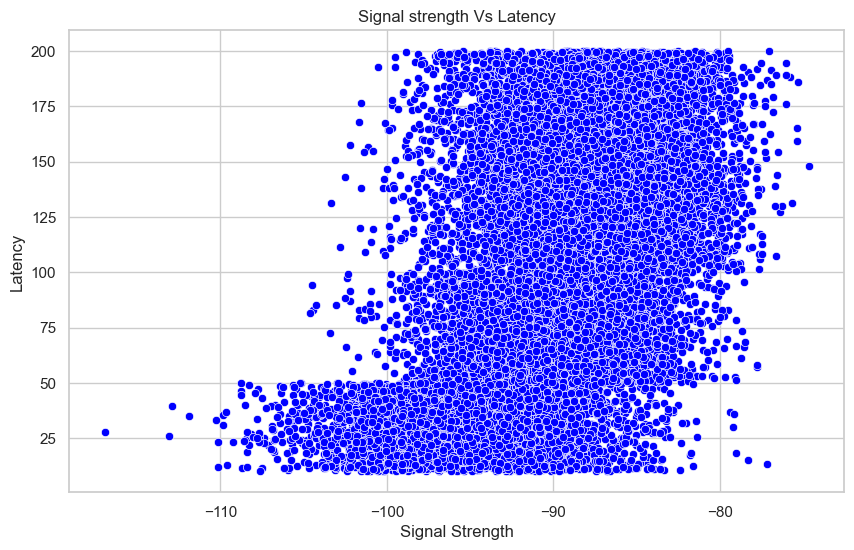

In [28]:
#Signal strength vs Latency
plt.figure(figsize=(10,6))
sns.scatterplot(x=df['signal_strength_(dbm)'],y=df['latency_(ms)'],color=('blue'),data=df)
plt.title('Signal strength Vs Latency')
plt.xlabel("Signal Strength")
plt.ylabel("Latency")
plt.show()

**Observations**

1. **Data Distribution** - "L" or "Shelf" Shape: The data points form a distinct "L" shape or a shape resembling a shelf.
 - There is a dense, broad horizontal band of points at lower Latency values (approximately 0 to 50), predominantly for Signal Strengths between -107 and -78.
 -Above this "shelf," for Signal Strengths roughly between -102 and -78, there's a very dense, tall, vertical-ish cluster of points where Latency ranges from around 50 up to 200.
 - This suggests two main modes of operation or conditions.

2. **Implied Relationship:**
 - Higher Signal Strength (less negative, e.g., -95 to -78): Latency can be either very low (the "shelf") or very high (the dense upper cluster), covering a wide range.
 - Lower Signal Strength (more negative, e.g., -102 to -107): Latency is primarily found in the lower range (the "shelf"), though there are some scattered points at higher latencies as well. This is somewhat counter-intuitive, as one might expect weaker signals to lead to higher latencies.
 - The transition between the lower Latency "shelf" and the higher Latency dense region seems to happen at a Latency of approximately 50.

3. **Dense Areas:**
 -The densest area is the large cluster at higher Latency values (50-200) across a significant range of Signal Strengths (-102 to -78).
 -Another dense area is the lower "shelf" where Latency is low, spanning a wide range of Signal Strengths.

### Categorical Vs Numeric

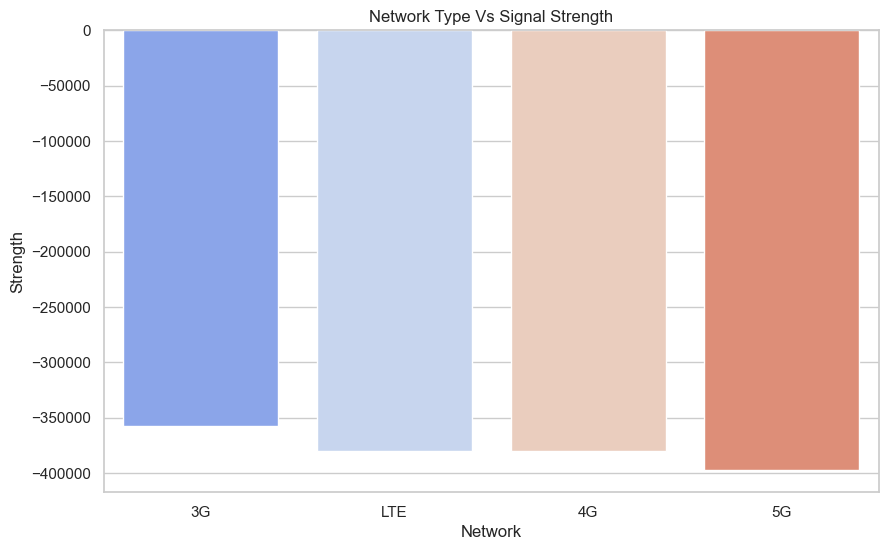

In [29]:
#Network Type vs Signal Strength
net_signals = df.groupby('network_type')['signal_strength_(dbm)'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=net_signals.index,y=net_signals.values,palette="coolwarm")
plt.title('Network Type Vs Signal Strength')
plt.xlabel('Network')
plt.ylabel('Strength')
plt.show()

**Observations**
- It appears that 3G has the least negative (strongest) signal strength among the observed network types, even though it's still very weak given the scale.
- LTE and 4G have very similar signal strengths, which are slightly weaker (more negative) than 3G.
- 5G has the most negative (weakest) signal strength among the categories.

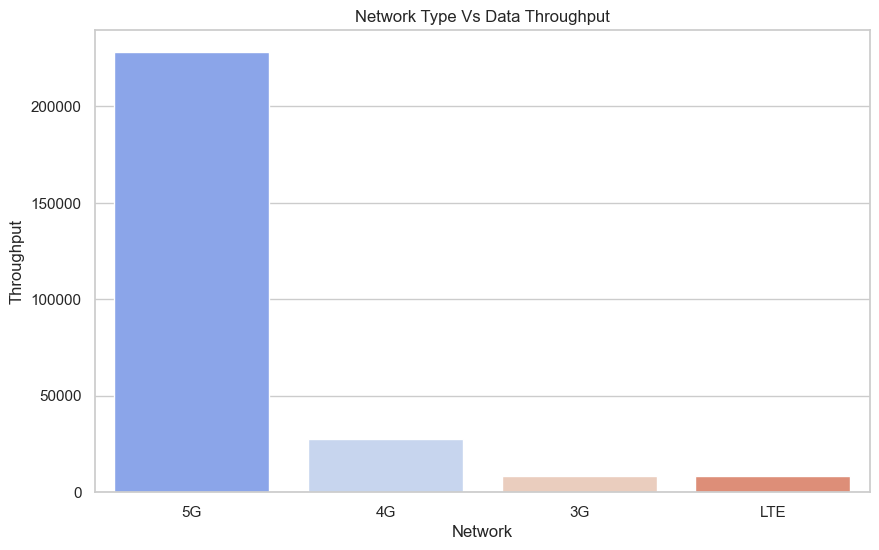

In [30]:
#Network Type vs Throughput
net_throughput = df.groupby('network_type')['data_throughput_(mbps)'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=net_throughput.index,y=net_throughput.values,palette="coolwarm")
plt.title('Network Type Vs Data Throughput')
plt.xlabel('Network')
plt.ylabel('Throughput')
plt.show()

**Observations**
- 5G demonstrates vastly superior Data Throughput compared to all other network types. It is an order of magnitude higher than 4G, and significantly higher than 3G and LTE.
- There's a clear descending trend in Data Throughput from 5G to 4G, then to 3G, and finally to LTE.

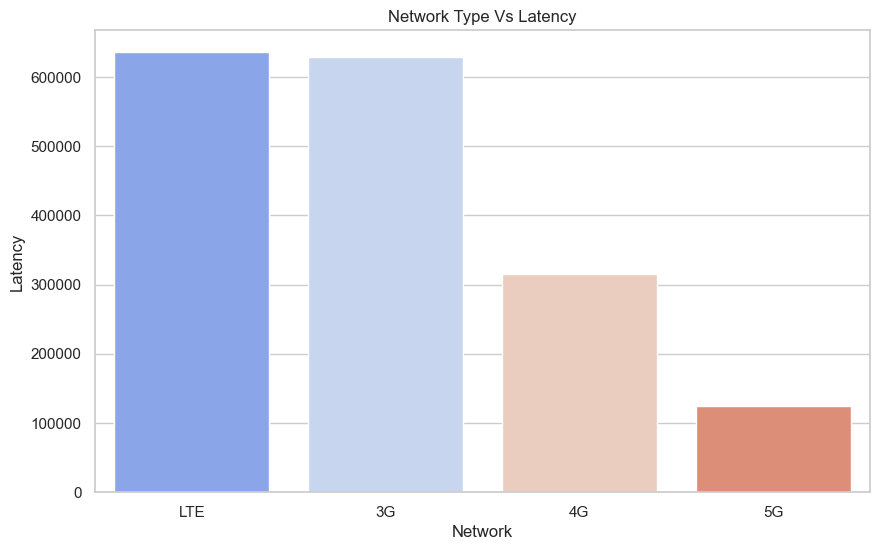

In [31]:
#Network Type vs latency
net_latency = df.groupby('network_type')['latency_(ms)'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=net_latency.index,y=net_latency.values,palette="coolwarm")
plt.title('Network Type Vs Latency')
plt.xlabel('Network')
plt.ylabel('Latency')
plt.show()

**Observations**
- LTE and 3G exhibit very high and similar Latency values, being the highest among the categories.
4G has considerably lower Latency compared to LTE and 3G.
- 5G demonstrates the lowest Latency by a significant margin, being less than half of 4G's latency and roughly one-fifth of LTE/3G's latency.
- Implied Performance Trend: This chart suggests that as network technology advances (from 3G/LTE to 4G and then to 5G), the associated latency generally decreases, with 5G offering the best (lowest) latency performance.

### Time Trends

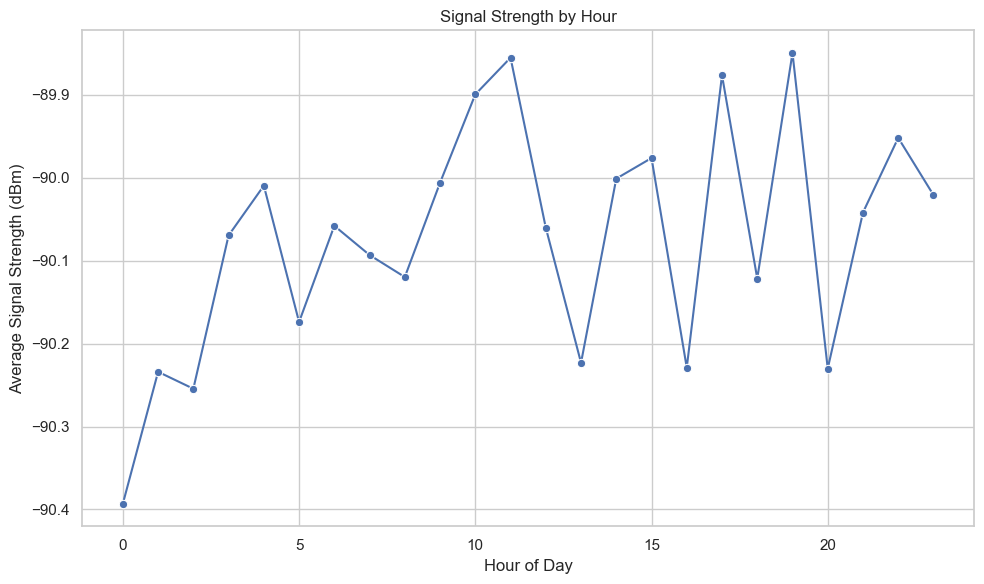

In [32]:
# Signal strength by hour
hourly_signals = df.groupby('hour')['signal_strength_(dbm)'].mean()

# Plot
plt.figure(figsize=(10, 6))
sns.lineplot(x=hourly_signals.index, y=hourly_signals.values,marker='o')
plt.title('Signal Strength by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Signal Strength (dBm)')
plt.grid(True)
plt.tight_layout()
plt.show()

**Observations**

- The signal strength fluctuates significantly throughout the day.
- Early Morning (0-2 hours): Starts around -90.4 dBm and then rises to about -90.25 dBm.
- Morning (3-10 hours): Generally shows an improving (less negative) trend, peaking around -89.85 dBm at hour 9 or 10.
- Daytime/Afternoon (11-17 hours): Exhibits more volatility. There's a dip around hour 12, then a rise, another dip around hour 16, and then a strong rise again around hour 18.
- Evening/Night (18-22 hours): Shows significant drops and rises, with another peak around hour 19, a sharp drop around hour 20, and then a recovery around hour 21 before a slight dip again at hour 22.

- Peaks and Troughs:
  - Strongest Signal (least negative): The signal appears strongest around hour 9-10 and hour 19, reaching values near -89.85 dBm.
  - Weakest Signal (most negative): The signal is weakest around hour 0 and hour 20, dropping to approximately -90.4 dBm and -90.25 dBm respectively.

- Overall Fluctuation: The overall difference between the strongest and weakest average signal strength is relatively small (approx. 0.55 dBm), indicating that while there are patterns, the absolute variation in average signal strength is not extreme.

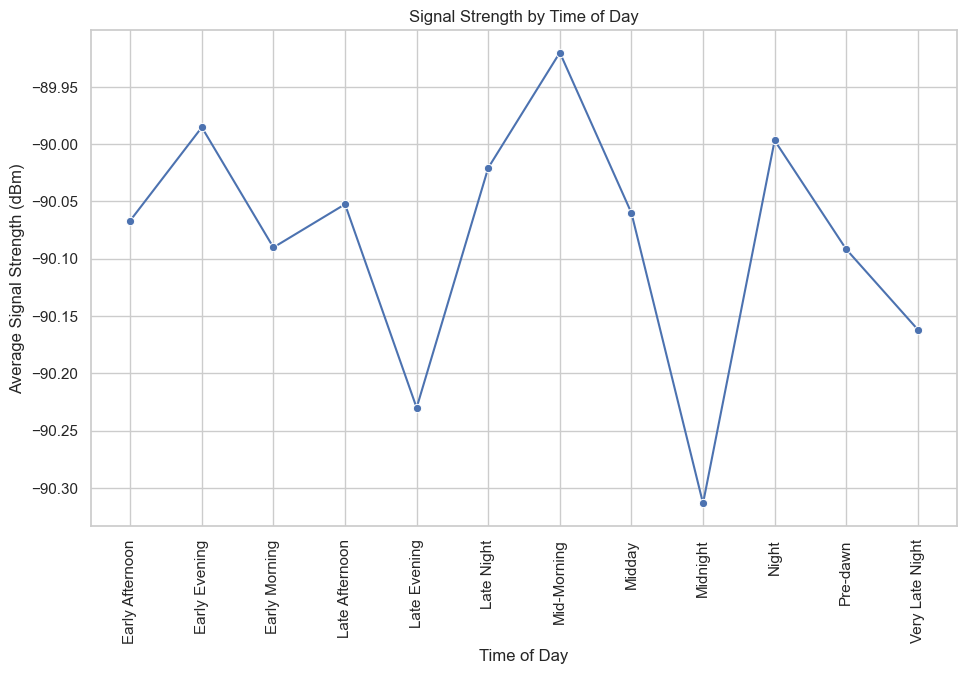

In [33]:
# signal strength by time of day
day_signals = df.groupby('time_of_day')['signal_strength_(dbm)'].mean()

# Plot
plt.figure(figsize=(10, 6))
sns.lineplot(x=day_signals.index, y=day_signals.values,marker='o')
plt.title('Signal Strength by Time of Day')
plt.xlabel('Time of Day')
plt.ylabel('Average Signal Strength (dBm)')
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=90)
plt.show()

**Observations**
1. **Signal Strength Trend:** The signal strength fluctuates significantly across the various times of the day.
- Strongest Signal (Least Negative): The signal appears strongest during Mid-Morning, peaking at approximately -89.8 dBm. There's another relatively strong period during Night (around -90.0 dBm).
- Weakest Signal (Most Negative): The signal is weakest at Midnight, dropping significantly to approximately -90.3 dBm. It also shows dips during Late Evening and Early Morning.

2. **Fluctuation Patterns:** The graph shows a clear diurnal pattern, with signal strength generally improving from early morning through mid-morning, then declining towards midday and late evening, a sharp drop at midnight, followed by a recovery into the night.

3. **Range of Fluctuation:** The difference between the strongest (Mid-Morning: ~-89.8 dBm) and weakest (Midnight: ~-90.3 dBm) average signal strength is relatively small (around 0.5 dBm), suggesting that while there are consistent patterns, the absolute variation in average signal strength is not extremely large.

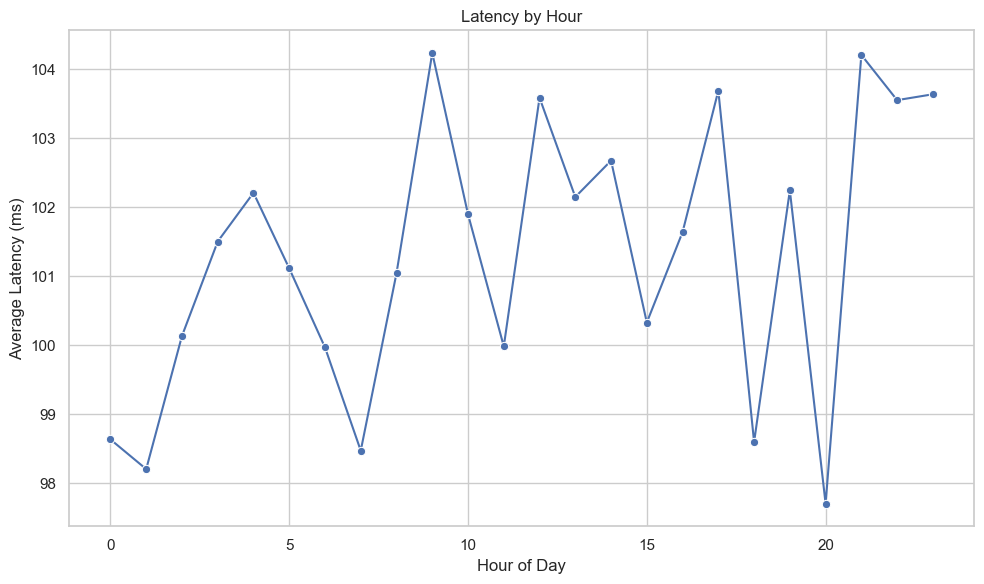

In [34]:
# Latency by hour
lat_signals = df.groupby('hour')['latency_(ms)'].mean()

# Plot
plt.figure(figsize=(10, 6))
sns.lineplot(x=lat_signals.index, y=lat_signals.values,marker='o')
plt.title('Latency by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Latency (ms)')
plt.grid(True)
plt.tight_layout()
plt.show()

**Observations**
1. **Latency Trend:** The average latency fluctuates significantly throughout the day.
- Early Hours (0-2): Starts around 98.6 ms, dips slightly to 98.2 ms at hour 1, and then begins to rise.
Morning (3-9): Shows a general upward trend, reaching a peak of over 104 ms around hour 9. There's a dip around hour 6.
- Midday/Afternoon (10-15): Shows considerable variability. A sharp drop at hour 10, then a rise to over 103 ms at hour 12, followed by another drop around hour 14.
- Evening/Night (16-22): Continues to show significant fluctuations. A peak around hour 17 (over 103.5 ms), a sharp drop to the lowest point of the day around hour 20 (below 98 ms), and then a rapid increase to another peak (over 104 ms) around hour 21, followed by a slight decrease.

2. **Peaks and Troughs:**
- Highest Latency: Peaks appear around hour 9 (over 104 ms), hour 17 (over 103.5 ms), and hour 21 (over 104 ms).
Lowest Latency: The lowest point occurs around hour 20 (below 98 ms), with another low point around hour 1 (around 98.2 ms).

- Overall Fluctuation: The latency varies by approximately 6-7 milliseconds throughout the day (from a low of <98 ms to a high of >104 ms), indicating a noticeable, though not extreme, daily pattern in average network response time.

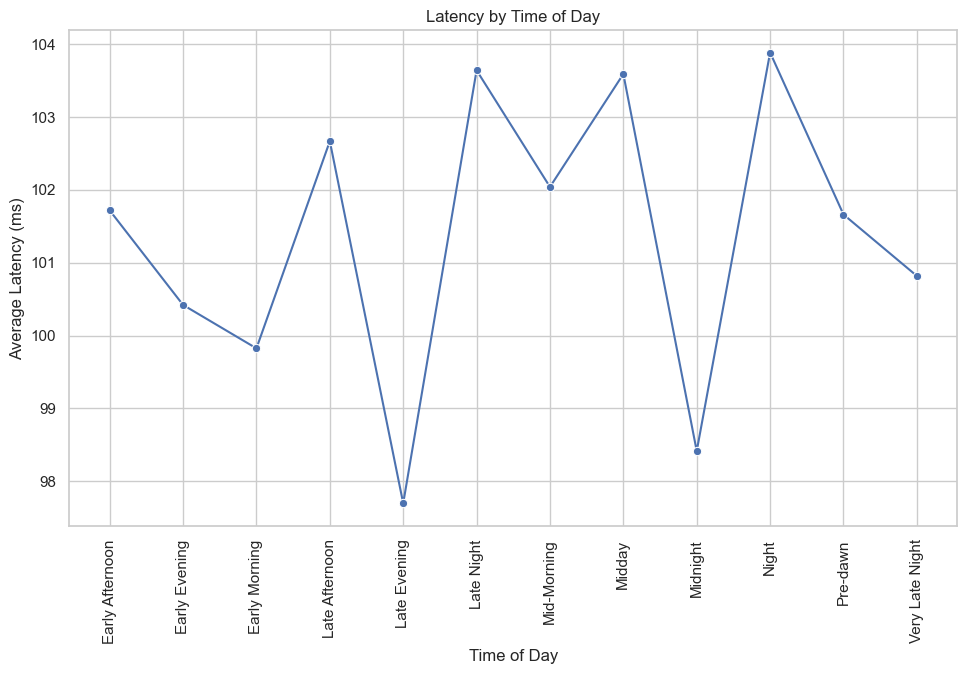

In [35]:
# Latency by time of day
day_lat = df.groupby('time_of_day')['latency_(ms)'].mean()

# Plot
plt.figure(figsize=(10, 6))
sns.lineplot(x=day_lat.index, y=day_lat.values,marker='o')
plt.title('Latency by Time of Day')
plt.xlabel('Time of Day')
plt.ylabel('Average Latency (ms)')
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=90)
plt.show()

**Observations**
- Latency Trend: The average latency fluctuates considerably across the different times of day, showing a distinct pattern.

- Peaks (Highest Latency):
  - Late Afternoon shows a high latency around 102.7 ms.
  - Late Night shows the highest latency, peaking at approximately 103.7 ms.
  - Midday also exhibits high latency, around 103.5 ms.
  - Night shows another peak, close to 104 ms.

- Troughs (Lowest Latency):
  - The lowest latency occurs during Late Evening, dropping significantly to approximately 97.7 ms.
  - Midnight also shows a relatively low latency around 98.4 ms.

- General Pattern: The pattern suggests fluctuations throughout the day. Latency appears to be higher in the late afternoon/early evening, late night, and midday, and lower in the late evening and midnight periods.

- Range of Fluctuation: The difference between the highest (Night: ~104 ms) and lowest (Late Evening: ~97.7 ms) average latency is approximately 6.3 milliseconds, indicating a noticeable daily variation in network responsiveness.

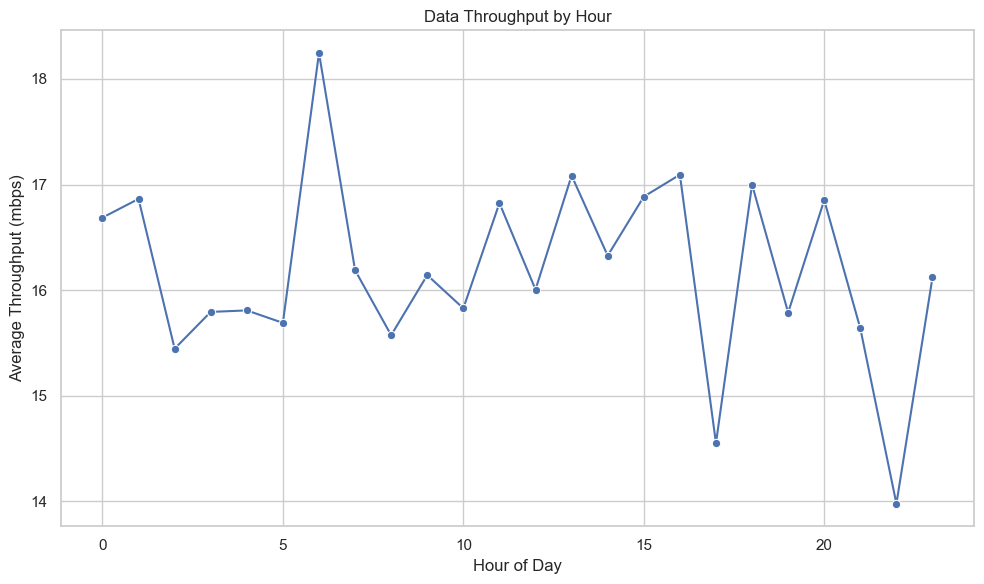

In [36]:
# Throughput by hour
data_hour = df.groupby('hour')['data_throughput_(mbps)'].mean()

# Plot
plt.figure(figsize=(10, 6))
sns.lineplot(x=data_hour.index, y=data_hour.values,marker='o')
plt.title('Data Throughput by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Throughput (mbps)')
plt.grid(True)
plt.tight_layout()
plt.show()

**Observations**
1. **Throughput Trend:** The average data throughput fluctuates significantly throughout the day, showing a highly dynamic pattern.
- Early Hours (0-2): Starts strong around 16.6 mbps, then dips to around 15.4 mbps at hour 2.
- Morning (3-6): Shows a slight increase, then a very sharp peak at hour 6, reaching over 18.2 mbps, which is the highest throughput observed in the plot.
- Late Morning/Midday (7-12): Experiences a sharp drop after the peak, followed by several smaller fluctuations.  There's a dip around hour 8 and then a recovery, another dip around hour 10, and a slight rise around hour 11.
- Afternoon (13-17): Generally shows an upward trend, reaching another peak around hour 16 (over 17 mbps).
- Evening/Night (18-22): Exhibits extreme volatility. A sharp drop around hour 18, a very significant drop to the lowest point of the day at hour 21 (around 14 mbps), followed by a notable recovery at hour 22.

2. **Peaks and Troughs:**
- Highest Throughput: The absolute highest throughput occurs at hour 6 (over 18.2 mbps). Other notable peaks are around hour 16 and hour 19.
- Lowest Throughput: The lowest throughput is observed at hour 21 (around 14 mbps), and also around hour 17 (around 14.5 mbps).

Overall Fluctuation: The data throughput varies by approximately 4-4.5 mbps throughout the day (from a low of ~14 mbps to a high of ~18.3 mbps). This represents a significant percentage fluctuation, indicating that network performance in terms of throughput is quite dynamic based on the hour.

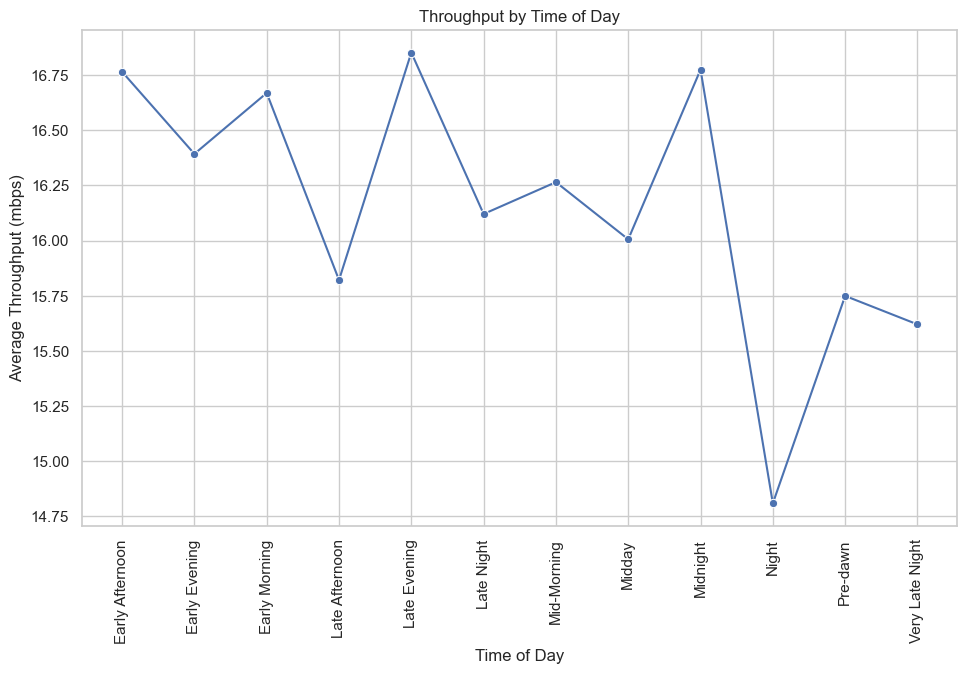

In [37]:
# Throughput by time of day
day_throughput = df.groupby('time_of_day')['data_throughput_(mbps)'].mean()

# Plot
plt.figure(figsize=(10, 6))
sns.lineplot(x=day_throughput.index, y=day_throughput.values,marker='o')
plt.title('Throughput by Time of Day')
plt.xlabel('Time of Day')
plt.ylabel('Average Throughput (mbps)')
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=90)
plt.show()

**Observations**
1. Throughput Trend: The average throughput fluctuates significantly across the different times of day, showing a distinct pattern.

2. Peaks (Highest Throughput):
- Late Evening shows the highest throughput, peaking at approximately 16.8 mbps.
- Early Afternoon and Midnight also exhibit high throughput, around 16.7 mbps.
- Early Morning is also relatively high at around 16.65 mbps.

3. Troughs (Lowest Throughput):
- The lowest throughput occurs during Night, dropping significantly to approximately 14.8 mbps.
- Late Afternoon also shows a dip to around 15.8 mbps.

4. General Pattern: The graph indicates a generally good throughput during early afternoon, early morning, late evening, and midnight. There are noticeable dips in throughput during late afternoon, and a very sharp drop during the "Night" period.

5. Range of Fluctuation: The difference between the highest (Late Evening: ~16.8 mbps) and lowest (Night: ~14.8 mbps) average throughput is approximately 2 mbps. This represents a noticeable, though not extreme, daily variation in network performance.

## Multi-variate Analysis

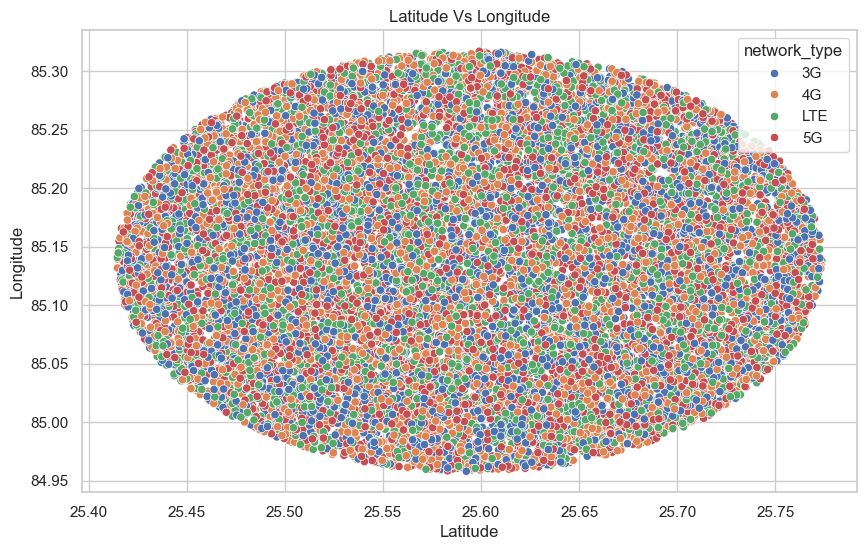

In [38]:
#Latitude vs Longitude in relation to Network Type
plt.figure(figsize=(10,6))
sns.scatterplot(x=df['latitude'],y=df['longitude'],hue=df['network_type'],data=df)
plt.title('Latitude Vs Longitude')
plt.xlabel("Latitude")
plt.ylabel("Longitude")
plt.show()

**Observations**
1. Geographic Distribution (Overall): The data points form a large, dense, oval or elliptical shape, suggesting a concentration of observations within a specific geographic area defined by the latitude and longitude ranges.
- Latitude (x-axis) ranges approximately from 25.40 to 25.75.
- Longitude (y-axis) ranges approximately from 84.95 to 85.30.

2. Distribution of Network Types:
- Within the overall oval shape, the different network_type points (3G, 4G, LTE, 5G) appear to be interspersed and uniformly mixed. There are no obvious clusters or segregation of specific network types to particular geographic regions within the observed area.
- This suggests that all four network types are available and measured across the entire geographical region represented by the scatter plot.

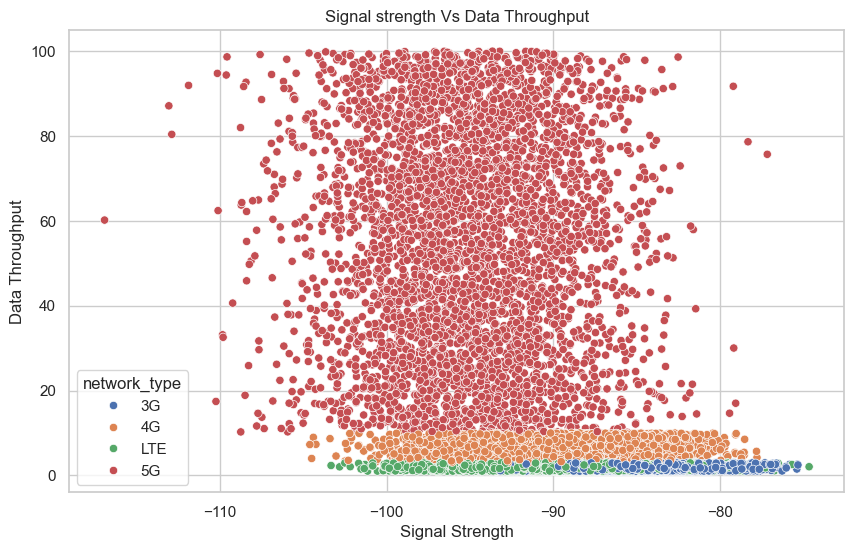

In [39]:
#Signal strength vs Throughput in relation to network type
plt.figure(figsize=(10,6))
sns.scatterplot(x=df['signal_strength_(dbm)'],y=df['data_throughput_(mbps)'],hue=df['network_type'],data=df)
plt.title('Signal strength Vs Data Throughput')
plt.xlabel("Signal Strength")
plt.ylabel("Data Throughput")
plt.show()

**Observations**
1. Overall Data Distribution: The data points form a wide, somewhat "inverted trapezoid" or "funnel" shape, similar to a previous observation, where throughput generally has a wider range at weaker signal strengths and a narrower range at stronger signal strengths, especially for 5G.

2. Distribution by Network Type: This is the most insightful observation due to the color encoding:
- 5G (red points): These points constitute the vast majority of observations at higher Data Throughput values (above ~10). They are broadly distributed across most Signal Strength values, from approximately -108 up to -78, covering the entire range of throughputs from near 0 up to 100. This suggests that 5G connections are responsible for almost all high-throughput data.
- 3G (blue points), 4G (orange points), and LTE (green points): These network types are primarily clustered at very low Data Throughput values, typically below 10.
- They form distinct, narrow horizontal bands at the bottom of the plot.
- LTE (green) appears to be slightly higher than 3G (blue), and 4G (orange) slightly higher than LTE, but all are clearly segregated to the very low throughput region.
- These network types are also predominantly observed at stronger signal strengths (less negative, generally from around -100 to -78).

3. Implied Performance Comparison:
- 5G clearly offers superior Data Throughput performance compared to 3G, 4G, and LTE. While 5G can also have low throughput, it's the only network type observed achieving high throughput.
- Conversely, 3G, 4G, and LTE are consistently associated with very low throughput, regardless of signal strength within their observed range.

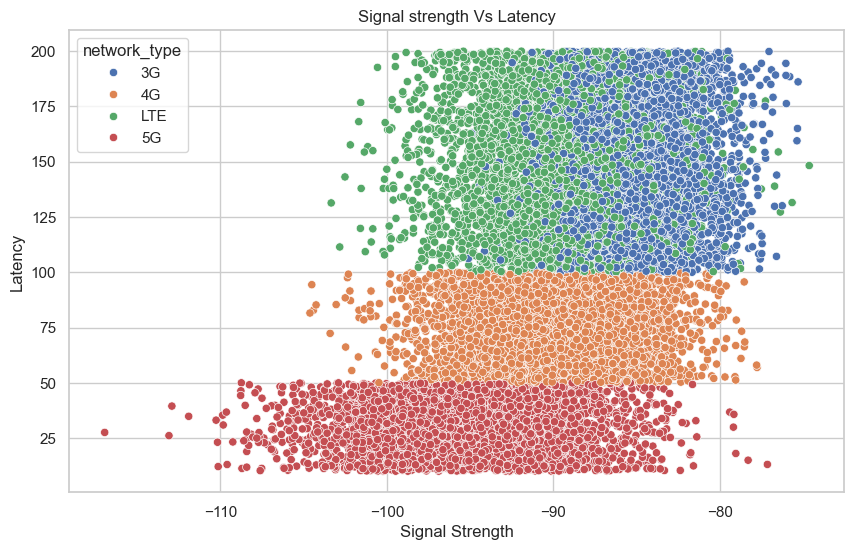

In [40]:
#Signal strength vs Latency in relation to Network Type
plt.figure(figsize=(10,6))
sns.scatterplot(x=df['signal_strength_(dbm)'],y=df['latency_(ms)'],hue=df['network_type'],data=df)
plt.title('Signal strength Vs Latency')
plt.xlabel("Signal Strength")
plt.ylabel("Latency")
plt.show()

**Observations**
1. Data Distribution by Network Type (Stratification): This is the most crucial observation. The data is distinctly stratified by network_type based on latency values, forming horizontal bands:
- 5G (red points): Primarily clustered at the lowest latency values, generally between 0 and 50. This band spans most of the observed signal strength range, from approximately -110 to -78.
- 4G (orange points): Clustered at a mid-range of latency values, roughly between 50 and 100. This band also spans a significant portion of the signal strength range, from about -100 to -78.
- 3G (blue points) and LTE (green points): These two network types are predominantly found at the highest latency values, ranging from approximately 100 to 200. They largely overlap in terms of latency range and signal strength distribution, covering from about -100 to -78 signal strength.

2. Implied Performance Comparison:
- 5G consistently demonstrates the lowest latency among all network types, regardless of signal strength.
- 4G offers moderate latency, significantly better than 3G and LTE, but not as good as 5G.
- 3G and LTE exhibit the highest latencies, with little apparent difference between them.

3. Signal Strength's Role: While latency is clearly differentiated by network type, within each network type's specific latency band, signal strength doesn't appear to strongly dictate latency in a simple linear fashion. The points within each band are broadly spread across the signal strength axis.

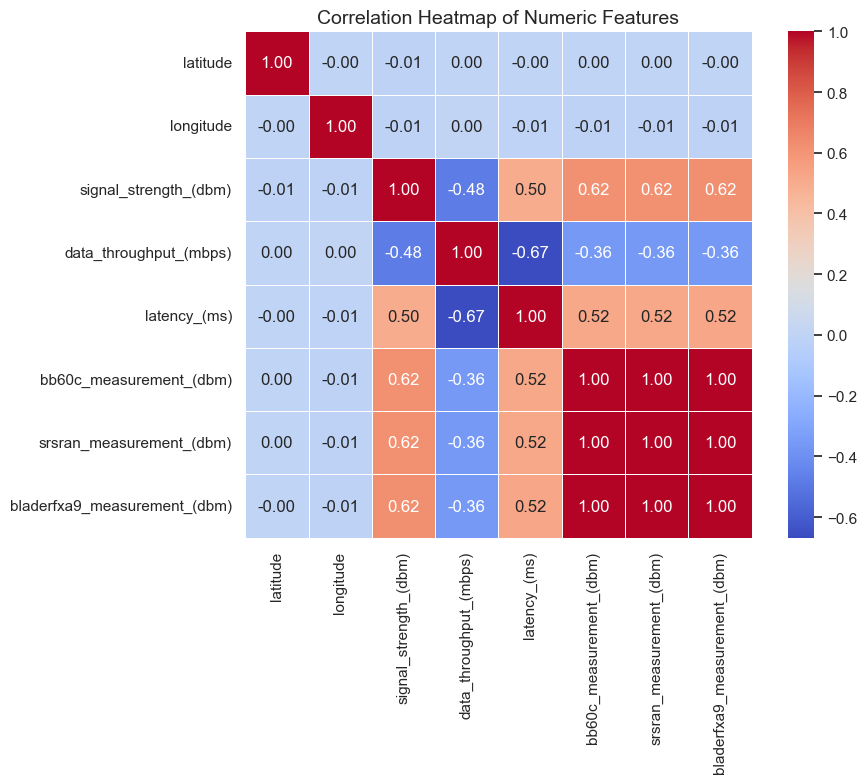

In [41]:
# Correlation heatmap
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features", fontsize=14)
plt.tight_layout()
plt.show()

**Observations**
1. Key Correlations:

- Signal Strength vs. Latency: There is a strong positive correlation of 0.50 between signal_strength_(dbm) and latency_(ms). This is highly counter-intuitive: it suggests that as signal strength increases (becomes less negative, closer to 0), latency also increases. This is a significant finding and goes against the typical expectation that stronger signals lead to lower latency.
- Signal Strength vs. Data Throughput: There is a strong negative correlation of -0.48 between signal_strength_(dbm) and data_throughput_(mbps). This is also counter-intuitive: it suggests that as signal strength increases, data throughput decreases. This aligns with the previous scatter plot observation where higher throughput was observed at weaker signal strengths for 5G.
- Data Throughput vs. Latency: There is a strong negative correlation of -0.67 between data_throughput_(mbps) and latency_(ms). This is an expected and logical correlation: as data throughput increases, latency decreases. This is a desirable relationship.

2. Measurement Variables:

- bb60c_measurement_(dbm), srsran_measurement_(dbm), and bladerfxa9_measurement_(dbm) are very highly positively correlated with signal_strength_(dbm) (0.62, 0.62, 0.62 respectively). This suggests these are likely alternative or related measurements of signal strength.
- These measurement variables also have moderate positive correlations with latency_(ms) (0.52, 0.52, 0.52) and moderate negative correlations with data_throughput_(mbps) (-0.36, -0.36, -0.36), consistent with their strong correlation to signal_strength_(dbm).

3. Latitude and Longitude:

- latitude and longitude show very weak or negligible correlations (close to 0.00 or -0.01) with all other network performance metrics (signal_strength, data_throughput, latency, and the measurement variables). This suggests that geographical location within the observed area does not have a strong linear relationship with these network performance indicators.

In [41]:
df.columns

Index(['timestamp', 'latitude', 'longitude', 'signal_strength_(dbm)',
       'data_throughput_(mbps)', 'latency_(ms)', 'network_type',
       'bb60c_measurement_(dbm)', 'srsran_measurement_(dbm)',
       'bladerfxa9_measurement_(dbm)', 'hour', 'day_of_week', 'month',
       'time_of_day'],
      dtype='object')

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16829 entries, 0 to 16828
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   timestamp                     16829 non-null  datetime64[ns]
 1   latitude                      16829 non-null  float64       
 2   longitude                     16829 non-null  float64       
 3   signal_strength_(dbm)         16829 non-null  float64       
 4   data_throughput_(mbps)        16829 non-null  float64       
 5   latency_(ms)                  16829 non-null  float64       
 6   network_type                  16829 non-null  object        
 7   bb60c_measurement_(dbm)       16829 non-null  float64       
 8   srsran_measurement_(dbm)      16829 non-null  float64       
 9   bladerfxa9_measurement_(dbm)  16829 non-null  float64       
 10  hour                          16829 non-null  int32         
 11  day_of_week                 

# Data Preprocessing

In [ ]:
# Define target
target = 'signal_strength_(dbm)'  

# encoding
le = LabelEncoder()
df['network_type'] = le.fit_transform(df['network_type'])
df['time_of_day'] = le.fit_transform(df['time_of_day'])

# Drop highly correlated features and target
features = df.drop(columns=['bb60c_measurement_(dbm)','srsran_measurement_(dbm)','bladerfxa9_measurement_(dbm)','signal_strength_(dbm)', 'timestamp'], axis=1).columns.tolist()  

# 
print(features)
# Define X and y
X = df[features]
y = df[target]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

['latitude', 'longitude', 'data_throughput_(mbps)', 'latency_(ms)', 'network_type', 'srsran_measurement_(dbm)', 'bladerfxa9_measurement_(dbm)', 'hour', 'day_of_week', 'month', 'time_of_day']


In [79]:
# scaling numeric features
numeric_features = X.select_dtypes(include=['float64', 'int64']).columns
scaler = StandardScaler()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])


# Modeling

## Regression

Here we will begin the regression modeling for signal strength and throughput
The major models include
1. Decision Tree regressor 
2. Random Forest regressor
3. XGBoost Regressor

In [80]:
# decision tree regressor
from sklearn.tree import DecisionTreeRegressor
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)


,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [81]:
#make predictions
y_pred = dt_model.predict(X_test)


In [82]:
# evaluate model
print("Decision Tree Regressor Performance:")
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))    
print("R^2 Score:", r2_score(y_test, y_pred))

Decision Tree Regressor Performance:
Mean Absolute Error: 1.788681023712243
Mean Squared Error: 6.67084827151973
R^2 Score: 0.7639560406813689


In [86]:
# Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [87]:
y_pred_rf = rf_model.predict(X_test)

In [88]:
# Evaluate Random Forest
print("Random Forest Regressor Performance:")
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_rf))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_rf))
print("R^2 Score:", r2_score(y_test, y_pred_rf))

Random Forest Regressor Performance:
Mean Absolute Error: 1.270339368515201
Mean Squared Error: 3.236568058473321
R^2 Score: 0.885475983258691


In [89]:
# xgboost regressor
xgb_model = XGBRegressor(random_state=42, n_estimators=100)
xgb_model.fit(X_train, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [90]:
y_pred_xgb = xgb_model.predict(X_test)

In [91]:
# evaluate model
print("XGBoost Regressor Performance:")
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_xgb))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_xgb))
print("R^2 Score:", r2_score(y_test, y_pred_xgb))   

XGBoost Regressor Performance:
Mean Absolute Error: 1.3337779565217418
Mean Squared Error: 3.5198345382208096
R^2 Score: 0.8754527690136134


In [92]:
# fine_tuning the decision tree regressor
param_grid = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
random_search = GridSearchCV(estimator=dt_model, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
random_search.fit(X_train, y_train)
print("Best parameters found:", random_search.best_params_)
print("Best cross-validation score:", random_search.best_score_)



Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters found: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best cross-validation score: 0.8766755963362179


In [93]:
# evaluate model    
best_dt_model = random_search.best_estimator_
y_pred_best_dt = best_dt_model.predict(X_test)
print("Tuned Decision Tree Regressor Performance:")
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_best_dt))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_best_dt))
print("R^2 Score:", r2_score(y_test, y_pred_best_dt))

Tuned Decision Tree Regressor Performance:
Mean Absolute Error: 1.3357752695001868
Mean Squared Error: 3.4023210108593407
R^2 Score: 0.8796109145961362


In [98]:
# tuning random forest regressor

from sklearn.model_selection import RandomizedSearchCV

param_grid_rf = {
    'n_estimators': [100, 200, 300, 500, 800],
    'max_depth': [None,5, 10, 15, 20, 30],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_features': [ 'sqrt', 'log2',0.5 , 0.7, 1.0]
}

raandomsearch_rf = RandomizedSearchCV(estimator=rf_model, param_distributions=param_grid_rf,
                                      n_iter=15, 
                                      cv=3, n_jobs=1, verbose=2, 
                                      random_state=42)
raandomsearch_rf.fit(X_train, y_train)

print("Best parameters found for Random Forest:", raandomsearch_rf.best_params_)
print("Best cross-validation score for Random Forest:", raandomsearch_rf.best_score_)



Fitting 3 folds for each of 15 candidates, totalling 45 fits
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=6, min_samples_split=2, n_estimators=100; total time=   2.4s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=6, min_samples_split=2, n_estimators=100; total time=   2.1s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=6, min_samples_split=2, n_estimators=100; total time=   2.1s
[CV] END max_depth=15, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=800; total time=  20.8s
[CV] END max_depth=15, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=800; total time=  20.8s
[CV] END max_depth=15, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=800; total time=  21.1s
[CV] END max_depth=10, max_features=1.0, min_samples_leaf=1, min_samples_split=10, n_estimators=100; total time=   8.1s
[CV] END max_depth=10, max_features=1.0, min_samples_leaf=1, min_samples_split=10, n_estimators=

In [99]:
# evaluate model
best_rf_model = raandomsearch_rf.best_estimator_
y_pred_best_rf = best_rf_model.predict(X_test)
print("Tuned Random Forest Regressor Performance:")
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_best_rf))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_best_rf))
print("R^2 Score:", r2_score(y_test, y_pred_best_rf))

Tuned Random Forest Regressor Performance:
Mean Absolute Error: 1.2496608333146442
Mean Squared Error: 3.114402220991083
R^2 Score: 0.8897987480404801


In [100]:
# tuning xgboost regressor
xgb_param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

random_search_xgb = RandomizedSearchCV(estimator=xgb_model, param_distributions=xgb_param_grid,
                                       n_iter=15, cv=3, n_jobs=-1, verbose=2, 
                                       random_state=42)

random_search_xgb.fit(X_train, y_train)
print("Best parameters found for XGBoost:", random_search_xgb.best_params_)
print("Best cross-validation score for XGBoost:", random_search_xgb.best_score_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best parameters found for XGBoost: {'subsample': 0.8, 'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
Best cross-validation score for XGBoost: 0.8883512443122094


In [101]:
# evaluate tuned xgboost

best_xgb_model = random_search_xgb.best_estimator_
y_pred_best_xgb = best_xgb_model.predict(X_test)
print("Tuned XGBoost Regressor Performance:")
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_best_xgb))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_best_xgb))
print("R^2 Score:", r2_score(y_test, y_pred_best_xgb))

Tuned XGBoost Regressor Performance:
Mean Absolute Error: 1.2699457809715102
Mean Squared Error: 3.16948046267516
R^2 Score: 0.8878498375406081


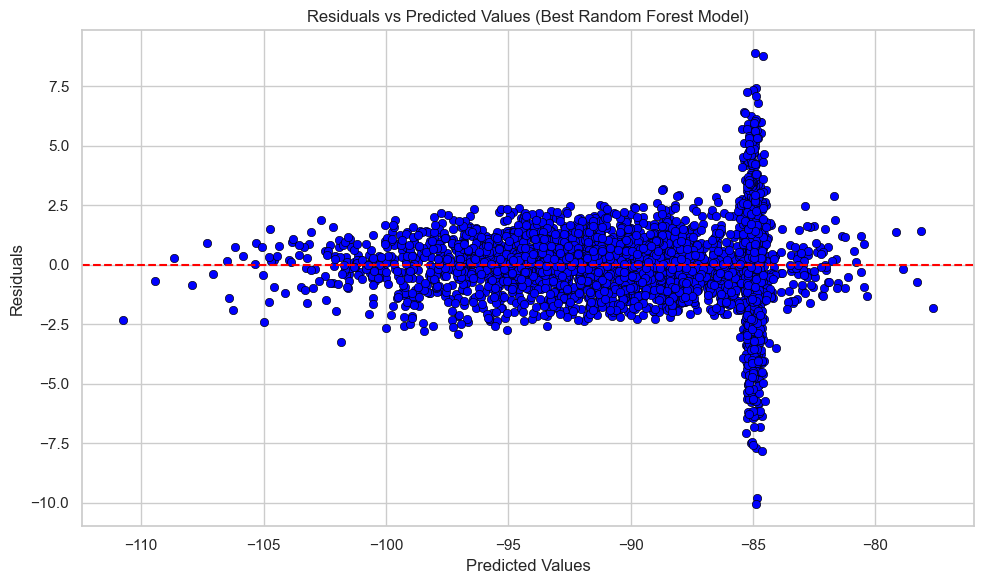

In [102]:
# plot residuals for the best model
residuals = y_test - y_pred_best_rf
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_best_rf, y=residuals, color='blue', edgecolor='black')
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs Predicted Values (Best Random Forest Model)')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.grid(True)
plt.tight_layout()
plt.show()

## Classification

In [122]:


# Drop highly correlated features and target
features = df.drop(columns=['bb60c_measurement_(dbm)','srsran_measurement_(dbm)','bladerfxa9_measurement_(dbm)','network_type', 'timestamp'], axis=1).columns.tolist()  

# 
print(features)
# Define X and y
X = df[features]
y = df['network_type']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

['latitude', 'longitude', 'signal_strength_(dbm)', 'data_throughput_(mbps)', 'latency_(ms)', 'hour', 'day_of_week', 'month', 'time_of_day']


In [123]:
#scaling numeric features
numeric_features = X.select_dtypes(include=['float64', 'int64']).columns
scaler = StandardScaler()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])


In [124]:
# decision tree classifier

from sklearn.tree import DecisionTreeClassifier

dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train)
y_pred_clf = dt_clf.predict(X_test)
print("Decision Tree Classifier Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_clf))
print("F1 Score:", f1_score(y_test, y_pred_clf, average='weighted'))
print("Classification Report:\n", classification_report(y_test, y_pred_clf))

Decision Tree Classifier Performance:
Accuracy: 0.8318478906714201
F1 Score: 0.8318271632548193
Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.65      0.66       842
           1       1.00      1.00      1.00       823
           2       1.00      1.00      1.00       853
           3       0.66      0.68      0.67       848

    accuracy                           0.83      3366
   macro avg       0.83      0.83      0.83      3366
weighted avg       0.83      0.83      0.83      3366



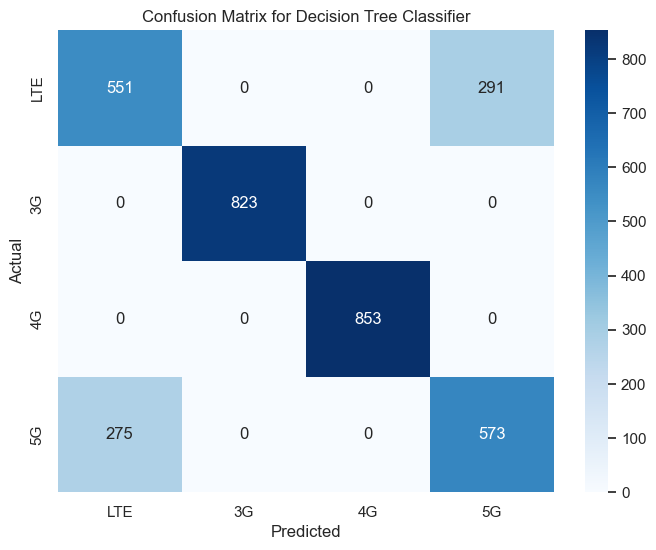

In [128]:
# plot confusion matrix
from sklearn.metrics import confusion_matrix

network_type_map = {0: 'LTE', 1: '3G', 2: '4G', 3: '5G'}
cm = confusion_matrix(y_test, y_pred_clf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=network_type_map.values(), yticklabels=network_type_map.values()  )
plt.title('Confusion Matrix for Decision Tree Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [129]:
# Fine-tuning Decision Tree Classifier
param_grid_clf = { 
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_search_clf = GridSearchCV(estimator=dt_clf, param_grid=param_grid_clf, cv=5, 
                               n_jobs=-1, verbose=2)
grid_search_clf.fit(X_train, y_train)
print("Best parameters found for Decision Tree Classifier:", grid_search_clf.best_params_)
print("Best cross-validation score for Decision Tree Classifier:", grid_search_clf.best_score_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters found for Decision Tree Classifier: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best cross-validation score for Decision Tree Classifier: 0.877887942378816


In [130]:
# evaluate tuned Decision Tree Classifier
best_dt_clf = grid_search_clf.best_estimator_
y_pred_best_dt_clf = best_dt_clf.predict(X_test)
print("Tuned Decision Tree Classifier Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_best_dt_clf))
print("F1 Score:", f1_score(y_test, y_pred_best_dt_clf, average='weighted'))
print("Classification Report:\n", classification_report(y_test, y_pred_best_dt_clf))


Tuned Decision Tree Classifier Performance:
Accuracy: 0.8773024361259656
F1 Score: 0.8751887178765788
Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.89      0.78       842
           1       1.00      1.00      1.00       823
           2       1.00      1.00      1.00       853
           3       0.85      0.62      0.72       848

    accuracy                           0.88      3366
   macro avg       0.89      0.88      0.88      3366
weighted avg       0.89      0.88      0.88      3366



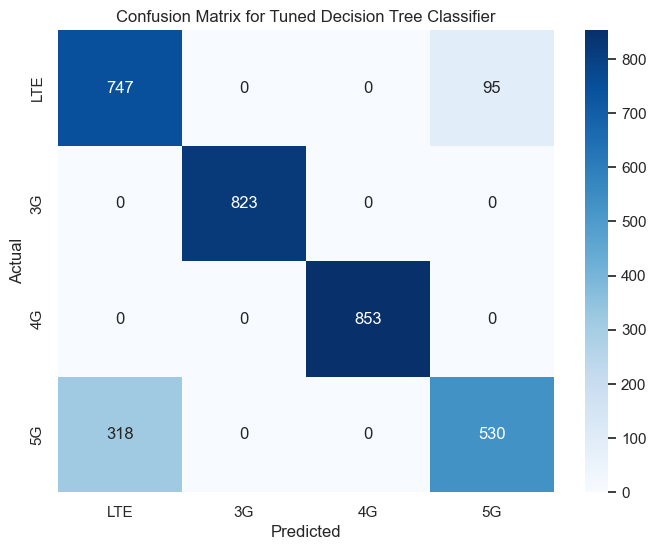

In [131]:
# plot confusion matrix of tuned model 
cm_tuned = confusion_matrix(y_test, y_pred_best_dt_clf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues', xticklabels=network_type_map.values(), yticklabels=network_type_map.values()  )
plt.title('Confusion Matrix for Tuned Decision Tree Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

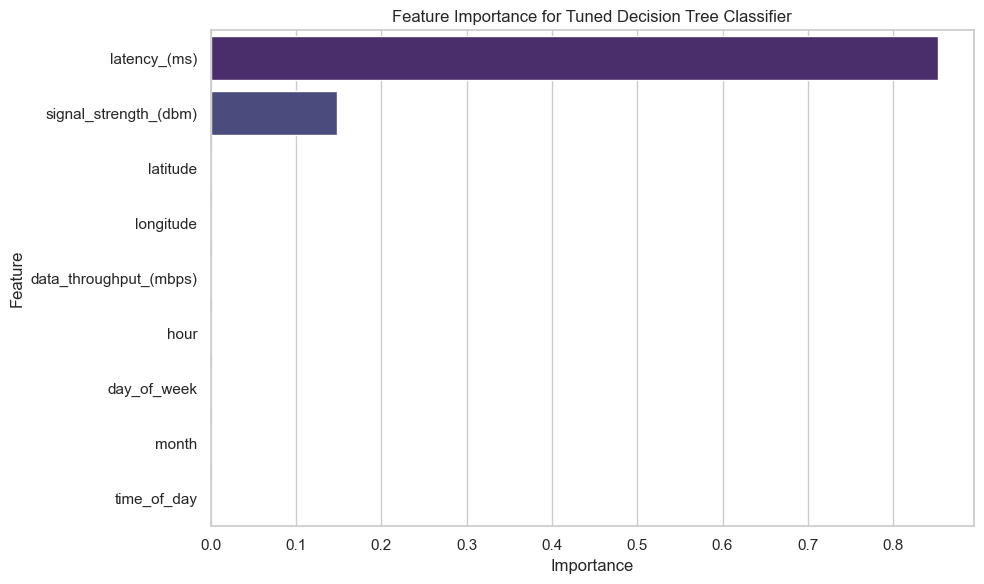

In [132]:
# feature importance for the best decision tree classifier
importances = best_dt_clf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False) 
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importance for Tuned Decision Tree Classifier')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [133]:
# random forest classifier
rf_clf = RandomForestClassifier(random_state=42, n_estimators=100)
rf_clf.fit(X_train, y_train)
y_pred_rf_clf = rf_clf.predict(X_test)
print("Random Forest Classifier Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf_clf))
print("F1 Score:", f1_score(y_test, y_pred_rf_clf, average='weighted'))
print("Classification Report:\n", classification_report(y_test, y_pred_rf_clf))

Random Forest Classifier Performance:
Accuracy: 0.8761140819964349
F1 Score: 0.8759475324167175
Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.79      0.76       842
           1       1.00      1.00      1.00       823
           2       1.00      1.00      1.00       853
           3       0.78      0.72      0.74       848

    accuracy                           0.88      3366
   macro avg       0.88      0.88      0.88      3366
weighted avg       0.88      0.88      0.88      3366



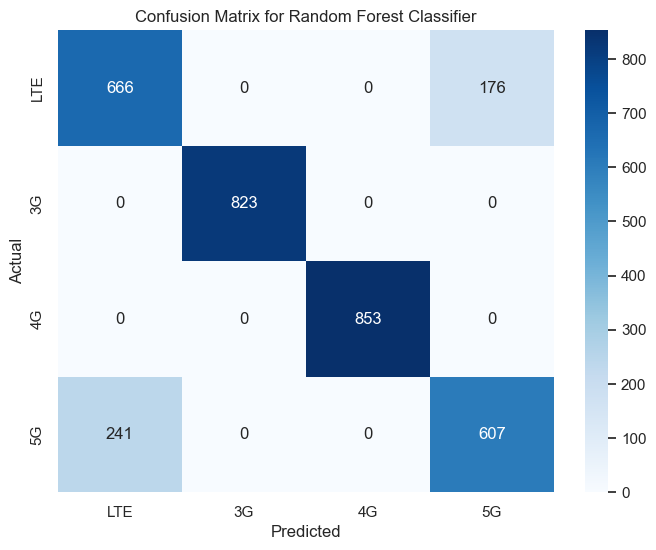

In [134]:
# plot confusion matrix for random forest model 
cm_rf = (confusion_matrix(y_test, y_pred_rf_clf))
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=network_type_map.values(), 
            yticklabels=network_type_map.values()  )
plt.title('Confusion Matrix for Random Forest Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [136]:
# tuning random forest classifier using hyperparameter tuning
param_grid_rf_clf = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_features': ['sqrt', 'log2', 0.5, 0.7, 1.0]
}
random_search_rf_clf = RandomizedSearchCV(estimator=rf_clf, param_distributions=param_grid_rf_clf,
                                          n_iter=15, cv=5, n_jobs=-1, 
                                          verbose=2, random_state=42)
random_search_rf_clf.fit(X_train, y_train)
print("Best parameters found for Random Forest Classifier:", random_search_rf_clf.best_params_)
print("Best cross-validation score for Random Forest Classifier:", random_search_rf_clf.best_score_)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best parameters found for Random Forest Classifier: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 5}
Best cross-validation score for Random Forest Classifier: 0.8779622917596608


In [137]:
# evaluate tuned Random Forest Classifier

best_rf_clf = random_search_rf_clf.best_estimator_
y_pred_best_rf_clf = best_rf_clf.predict(X_test)
print("Tuned Random Forest Classifier Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_best_rf_clf))
print("F1 Score:", f1_score(y_test, y_pred_best_rf_clf, average='weighted'))
print("Classification Report:\n", classification_report(y_test, y_pred_best_rf_clf))


Tuned Random Forest Classifier Performance:
Accuracy: 0.8823529411764706
F1 Score: 0.8812761753170292
Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.86      0.79       842
           1       1.00      1.00      1.00       823
           2       1.00      1.00      1.00       853
           3       0.83      0.67      0.74       848

    accuracy                           0.88      3366
   macro avg       0.89      0.88      0.88      3366
weighted avg       0.89      0.88      0.88      3366



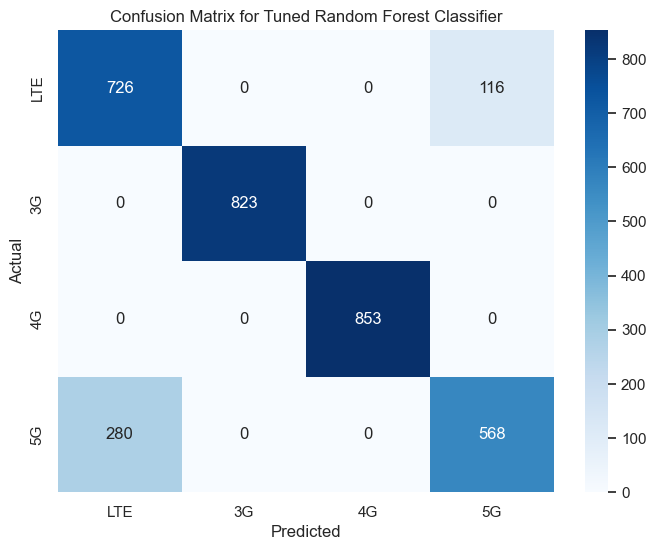

In [138]:
# plot confusion matrix for random forest classifier
cm_rf_clf = confusion_matrix(y_test, y_pred_best_rf_clf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf_clf, annot=True, fmt='d', cmap='Blues', xticklabels=network_type_map.values(), 
            yticklabels=network_type_map.values()  )
plt.title('Confusion Matrix for Tuned Random Forest Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


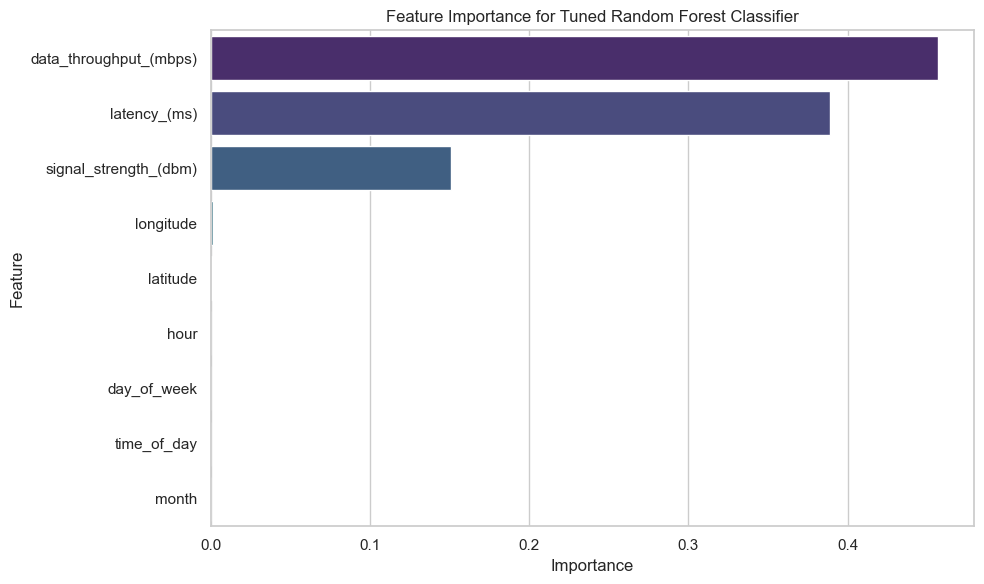

In [139]:
# feature importance for the best random forest classifier
importances_rf = best_rf_clf.feature_importances_
feature_importance_rf_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances_rf})
feature_importance_rf_df = feature_importance_rf_df.sort_values(by='Importance', ascending=False
)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_rf_df, palette='viridis')
plt.title('Feature Importance for Tuned Random Forest Classifier')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


In [140]:
# xgboost classifier
xgb_clf = XGBClassifier(random_state=42, n_estimators=100)
xgb_clf.fit(X_train, y_train)
y_pred_xgb_clf = xgb_clf.predict(X_test)
print("XGBoost Classifier Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb_clf))
print("F1 Score:", f1_score(y_test, y_pred_xgb_clf, average='weighted'))
print("Classification Report:\n", classification_report(y_test, y_pred_xgb_clf))


XGBoost Classifier Performance:
Accuracy: 0.8666072489601901
F1 Score: 0.8665401992302572
Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.76      0.74       842
           1       1.00      1.00      1.00       823
           2       1.00      1.00      1.00       853
           3       0.75      0.71      0.73       848

    accuracy                           0.87      3366
   macro avg       0.87      0.87      0.87      3366
weighted avg       0.87      0.87      0.87      3366



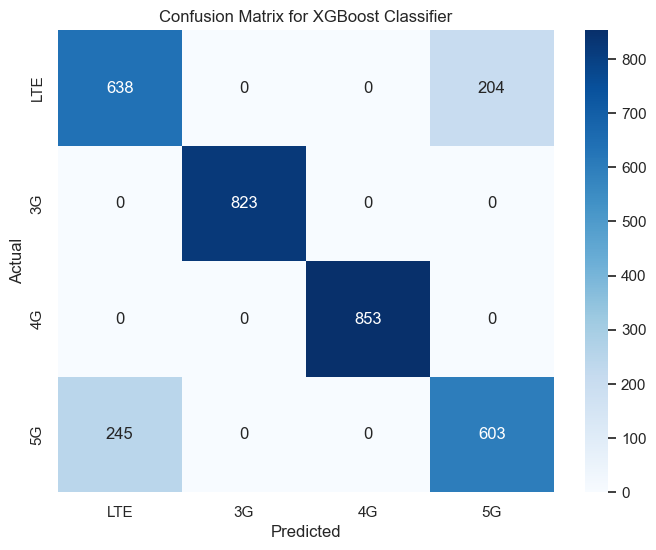

In [141]:
# plot the confusion matrix
cm_xgb_clf = confusion_matrix(y_test, y_pred_xgb_clf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb_clf, annot=True, fmt='d', cmap='Blues', xticklabels=network_type_map.values(), 
            yticklabels=network_type_map.values()  )
plt.title('Confusion Matrix for XGBoost Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [142]:
# tuning the xgboost model
xgb_param_grid_clf = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}
random_search_xgb_clf = RandomizedSearchCV(estimator=xgb_clf, param_distributions=xgb_param_grid_clf,
                                           n_iter=15, cv=5, n_jobs=-1, verbose=2,
                                             random_state=42)
random_search_xgb_clf.fit(X_train, y_train)
print("Best parameters found for XGBoost Classifier:", random_search_xgb_clf.best_params_)
print("Best cross-validation score for XGBoost Classifier:", random_search_xgb_clf.best_score_)


Fitting 5 folds for each of 15 candidates, totalling 75 fitsThe history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.

Best parameters found for XGBoost Classifier: {'subsample': 0.8, 'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
Best cross-validation score for XGBoost Classifier: 0.88004219844636


In [143]:
# evaluate the tuned xgboost

best_xgb_clf = random_search_xgb_clf.best_estimator_
y_pred_best_xgb_clf = best_xgb_clf.predict(X_test)
print("Tuned XGBoost Classifier Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_best_xgb_clf))
print("F1 Score:", f1_score(y_test, y_pred_best_xgb_clf, average='weighted'))
print("Classification Report:\n", classification_report(y_test, y_pred_best_xgb_clf))


Tuned XGBoost Classifier Performance:
Accuracy: 0.88116458704694
F1 Score: 0.8809889330730294
Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.80      0.77       842
           1       1.00      1.00      1.00       823
           2       1.00      1.00      1.00       853
           3       0.79      0.72      0.75       848

    accuracy                           0.88      3366
   macro avg       0.88      0.88      0.88      3366
weighted avg       0.88      0.88      0.88      3366



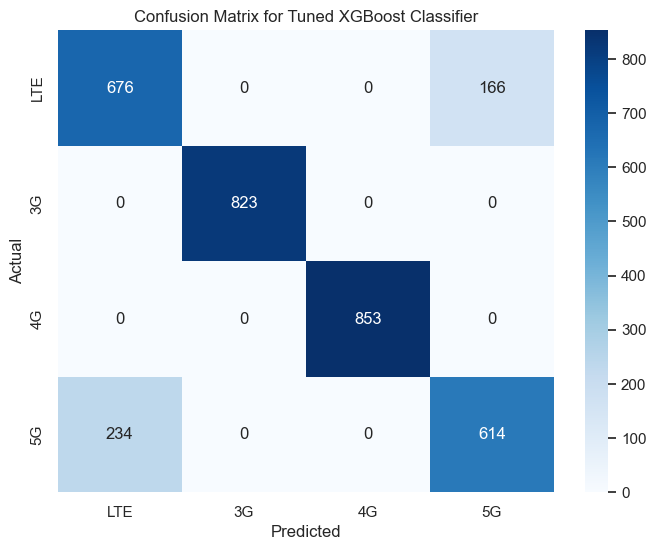

In [144]:
#plot the confusion matrix
cm_xgb_clf_tuned = confusion_matrix(y_test, y_pred_best_xgb_clf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb_clf_tuned, annot=True, fmt='d', cmap='Blues', xticklabels=network_type_map.values(), 
            yticklabels=network_type_map.values()  )
plt.title('Confusion Matrix for Tuned XGBoost Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

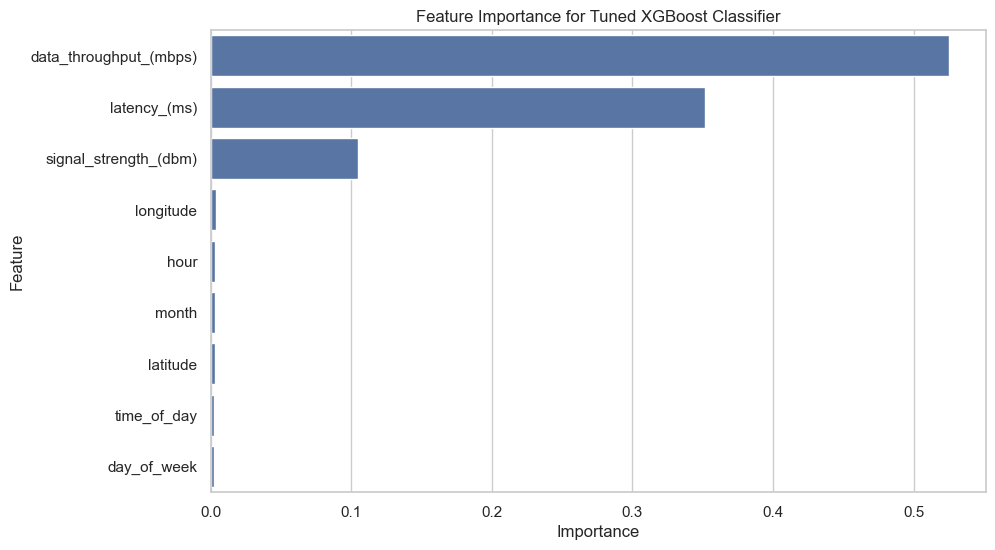

In [145]:
# feature importance for the best xgboost classifier
importances_xgb = best_xgb_clf.feature_importances_
feature_importance_xgb_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances_xgb})
feature_importance_xgb_df = feature_importance_xgb_df.sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_xgb_df, x='Importance', y='Feature')
plt.title('Feature Importance for Tuned XGBoost Classifier')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

# Deployment

In [74]:
import streamlit as st
import joblib

# Load the trained model
import joblib
# `xgb_model`
joblib.dump(xgb_model, "best_xgb.pkl")

model = joblib.load("best_xgb.pkl")

# Define input fields
st.title("📡 Signal Strength Predictor")

st.markdown("Enter the following information to predict signal strength (dBm):")

# User inputs
latitude = st.number_input("Latitude", value=0.0, format="%.6f")
longitude = st.number_input("Longitude", value=0.0, format="%.6f")
data_throughput = st.number_input("Data Throughput (Mbps)", value=1.0)
latency = st.number_input("Latency (ms)", value=1.0)

network_type = st.selectbox("Network Type", ["3G", "4G", "LTE", "5G"])

bb60c = st.number_input("BB60C Measurement (dBm)", value=-90.0)
srsran = st.number_input("SRSRAN Measurement (dBm)", value=-90.0)
bladerfx = st.number_input("BladeRFxA9 Measurement (dBm)", value=-90.0)

hour = st.slider("Hour of Day", 0, 23, 12)
day_of_week = st.selectbox("Day of Week", ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
month = st.selectbox("Month", list(range(1, 13)))

# Encoding mappings
day_map = {'Monday': 0, 'Tuesday': 1, 'Wednesday': 2,
           'Thursday': 3, 'Friday': 4, 'Saturday': 5, 'Sunday': 6}
network_map = {'3G': 0, '4G': 1, 'LTE': 2, '5G': 3}

# Prepare input for prediction
if st.button("Predict Signal Strength"):
    input_data = pd.DataFrame([{
        'latitude': latitude,
        'longitude': longitude,
        'data_throughput_(mbps)': data_throughput,
        'latency_(ms)': latency,
        'network_type': network_map[network_type],
        'bb60c_measurement_(dbm)': bb60c,
        'srsran_measurement_(dbm)': srsran,
        'bladerfxa9_measurement_(dbm)': bladerfx,
        'hour': hour,
        'day_of_week': day_map[day_of_week],
        'month': month
    }])

    # Prediction
    prediction = model.predict(input_data)[0]
    st.success(f"📶 Predicted Signal Strength: **{prediction:.2f} dBm**")


2025-07-16 14:09:04.398 
  command:

    streamlit run c:\Users\PC\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2025-07-16 14:09:04.400 Session state does not function when running a script without `streamlit run`


In [75]:
joblib.dump(xgb_pipe_throughput, "throughput_model.pkl")
print("✅ Throughput model saved")


✅ Throughput model saved


In [76]:
# Save preprocessor and model
joblib.dump(preprocessor, "preprocessor.pkl")
model.save_model("throughput_model.json")

print("✅ Model and preprocessor saved successfully.")


✅ Model and preprocessor saved successfully.


In [77]:
# Save model
joblib.dump(model, "throughput_model.pkl")

print("Model saved successfully.")


Model saved successfully.
